In [2]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import EditedNearestNeighbours
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf
import pickle
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dot
from tensorflow.keras.layers import Lambda
from tensorflow.keras import backend as K
import keras
import random
import numpy as np
import os
from PIL import Image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy


2024-05-14 16:44:05.501455: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-14 16:44:05.501548: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-14 16:44:05.604340: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [15]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import EditedNearestNeighbours
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf
import pickle
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dot
from tensorflow.keras.layers import Lambda
from tensorflow.keras import backend as K
import keras
import random
import numpy as np
import os
from PIL import Image
from tensorflow.keras.utils import to_categorical

In [3]:
def load_images_from_folder(folder):
    images = []
    labels = []
    for class_label, class_name in enumerate(sorted(os.listdir(folder))):
        class_folder = os.path.join(folder, class_name)
        for filename in os.listdir(class_folder):
            img_path = os.path.join(class_folder, filename)
            img = Image.open(img_path)
            img = img.resize((64, 64))  
            img = np.array(img)
            if img is not None:
                images.append(img)
                labels.append(class_label)
    return np.array(images), np.array(labels)

# Assuming your dataset is stored in a folder called 'dataset'
dataset_folder = '/kaggle/input/paddydoctormedium'

# Load images and labels from the dataset folder
x_data, y_data = load_images_from_folder(dataset_folder)

# Shuffle the data
random_indices = np.random.permutation(len(x_data))
x_data = x_data[random_indices]
y_data = y_data[random_indices]

# Split the data into training and testing sets (assuming 80-20 split)
split_idx = int(0.8 * len(x_data))
x_train, x_test = x_data[:split_idx], x_data[split_idx:]
y_train, y_test = y_data[:split_idx], y_data[split_idx:]

# Normalize the pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the images
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the data generator with augmentation options
datagen = ImageDataGenerator(
    rotation_range=20,      # Random rotation in the range [-20, 20] degrees
    width_shift_range=0.1,  # Random horizontal shift by 10% of the width
    height_shift_range=0.1, # Random vertical shift by 10% of the height
    shear_range=0.2,        # Shear intensity (shear angle in radians)
    zoom_range=0.2,         # Random zoom by 20%
    horizontal_flip=True,   # Random horizontal flip
    fill_mode='nearest'     # Fill mode for points outside the input boundaries
)

In [5]:
x_train = x_train.reshape(-1, 64, 64, 3)

In [6]:
datagen.fit(x_train)

# Example of using the data generator to augment data during training
augmented_data_generator = datagen.flow(x_train, y_train, batch_size=32)

In [7]:
x_train = x_train.reshape(x_train.shape[0],-1)

In [8]:
borderline_smote = SMOTE(random_state=42)
x_train_bls, y_train_bls = borderline_smote.fit_resample(x_train, y_train)

In [9]:
num_classes = len(np.unique(y_train_bls))
y_train_one_hot = to_categorical(y_train_bls, num_classes)
y_test_one_hot = to_categorical(y_test, num_classes)

In [10]:
x_train_bls = x_train_bls.reshape(-1, 64, 64, 3)
x_test = x_test.reshape(-1, 64, 64, 3)


In [11]:
class VisionTransformer(tf.keras.Model):
    def __init__(self, image_size, num_classes, patch_size, num_layers, d_model, num_heads, mlp_dim, dropout_rate=0.3):
        super(VisionTransformer, self).__init__()

        num_patches = (image_size // patch_size) ** 2
        self.patch_dim = 3 * patch_size ** 2  # Assuming input images are RGB

        # Patch embeddings
        self.patch_embeddings = tf.keras.layers.Conv2D(d_model, kernel_size=patch_size, strides=patch_size, padding='valid', input_shape=(image_size, image_size, 3))

        # Positional embeddings
        self.positional_embeddings = tf.keras.layers.Embedding(input_dim=num_patches, output_dim=d_model)

        # Transformer encoder layers
        self.encoder_layers = [TransformerEncoderLayer(d_model, num_heads, mlp_dim, dropout_rate) for _ in range(num_layers)]

        # Classification head
        self.classification_head = tf.keras.layers.Dense(num_classes)

    def call(self, inputs):
        # Patch extraction and embedding
        patches = self.patch_embeddings(inputs)
        batch_size = tf.shape(patches)[0]
        patch_dim = tf.shape(patches)[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])

        # Add positional embeddings
        positions = tf.range(start=0, limit=tf.shape(patches)[1], delta=1)
        positions = self.positional_embeddings(positions)

        # Add positional encodings to patch embeddings
        embeddings = patches + positions

        # Transformer encoding
        for encoder_layer in self.encoder_layers:
            embeddings = encoder_layer(embeddings)

        # Classification head
        logits = self.classification_head(embeddings[:, 0])

        return logits

class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, mlp_dim, dropout_rate=0.3):
        super(TransformerEncoderLayer, self).__init__()
        self.attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(mlp_dim, activation='relu'),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(d_model)
        ])
        self.layer_norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, inputs):
        # Self-attention
        attention_output = self.attention(inputs, inputs)
        attention_output = self.dropout1(attention_output)
        # Residual connection and layer normalization
        attention_output = self.layer_norm1(inputs + attention_output)

        # Feedforward network
        ffn_output = self.ffn(attention_output)
        ffn_output = self.dropout2(ffn_output)
        # Residual connection and layer normalization
        ffn_output = self.layer_norm2(attention_output + ffn_output)

        return ffn_output

In [12]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.915:
            self.model.stop_training = True

# Instantiate the custom callback
callback1 = CustomCallback()

In [13]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    # Add more Conv2D and MaxPooling2D layers as needed
])

# Define the Vision Transformer (ViT) model
class VisionTransformer(tf.keras.Model):
    def __init__(self, num_classes, patch_size, num_layers, d_model, num_heads, mlp_dim, dropout_rate=0.3):
        super(VisionTransformer, self).__init__()

        # Patch embeddings
        num_patches = (64 // patch_size) ** 2
        self.patch_dim = 64  # Output channels of the CNN
        self.patch_embeddings = tf.keras.layers.Conv2D(d_model, kernel_size=patch_size, strides=patch_size, padding='valid', activation='relu')

        # Positional embeddings
        self.positional_embeddings = tf.keras.layers.Embedding(input_dim=num_patches, output_dim=d_model)

        # Transformer encoder layers
        self.encoder_layers = [TransformerEncoderLayer(d_model, num_heads, mlp_dim, dropout_rate) for _ in range(num_layers)]

        # Classification head
        self.classification_head = tf.keras.layers.Dense(num_classes)

    def call(self, inputs):
        # CNN feature extraction
        cnn_features = cnn_model(inputs)

        # Patch embedding
        patches = self.patch_embeddings(cnn_features)
        batch_size = tf.shape(patches)[0]
        patch_dim = tf.shape(patches)[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])

        # Add positional embeddings
        positions = tf.range(start=0, limit=tf.shape(patches)[1], delta=1)
        positions = self.positional_embeddings(positions)

        # Add positional encodings to patch embeddings
        embeddings = patches + positions

        # Transformer encoding
        for encoder_layer in self.encoder_layers:
            embeddings = encoder_layer(embeddings)

        # Classification head
        logits = self.classification_head(embeddings[:, 0])

        return logits
    
    
    
    def get_config(self):
        config = super(VisionTransformer, self).get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# Instantiate the ViT model
model1 = VisionTransformer(num_classes=13, patch_size=8, num_layers=6, d_model=256, num_heads=8, mlp_dim=512)

# Compile the model
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

# Train the model
history1 = model1.fit(x_train_bls, y_train_bls, epochs=100, batch_size=64, validation_data=(x_test, y_test),callbacks = callback1)

# Evaluate the model


/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/100
  2/395 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.0391 - loss: 3.4348   

I0000 00:00:1715705262.691288     202 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1715705262.727992     202 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.1235 - loss: 2.6030

W0000 00:00:1715705288.395591     202 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1715705290.981783     202 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


395/395 ━━━━━━━━━━━━━━━━━━━━ 57s 79ms/step - accuracy: 0.1238 - loss: 2.6023 - val_accuracy: 0.3763 - val_loss: 1.8906
Epoch 2/100
  3/395 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5295 - loss: 1.5120

W0000 00:00:1715705293.852803     205 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.5985 - loss: 1.2618 - val_accuracy: 0.6191 - val_loss: 1.1903
Epoch 3/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.8382 - loss: 0.5165 - val_accuracy: 0.7590 - val_loss: 0.7851
Epoch 4/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.9224 - loss: 0.2529 - val_accuracy: 0.8216 - val_loss: 0.6194
Epoch 5/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9554 - loss: 0.1436 - val_accuracy: 0.8499 - val_loss: 0.5186
Epoch 6/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9683 - loss: 0.1034 - val_accuracy: 0.8496 - val_loss: 0.5487
Epoch 7/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9750 - loss: 0.0857 - val_accuracy: 0.8508 - val_loss: 0.5157
Epoch 8/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9801 - loss: 0.0693 - val_accuracy: 0.8656 - val_loss: 0.5129
Epoch 9/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9802 - loss: 0.0694 - val_

In [17]:
from keras.layers import Conv2D, AveragePooling2D, UpSampling2D
from keras.layers import add


def initial_octconv(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                    alpha=0.5, padding='same', dilation=None, bias=False):
    """
    Initializes the Octave Convolution architecture.

    Accepts a single input tensor, and returns a pair of tensors.
    The first tensor is the high frequency pathway.
    The second tensor is the low frequency pathway.

    # Arguments:
        ip: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a pair of tensors:
            - x_high: high frequency pathway.
            - x_low: low frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    high_low_filters = int(alpha * filters)
    high_high_filters = filters - high_low_filters

    if strides[0] > 1:
        ip = AveragePooling2D()(ip)

    # High path
    x_high = Conv2D(high_high_filters, kernel_size, padding=padding,
                    dilation_rate=dilation, use_bias=bias,
                    kernel_initializer='he_normal')(ip)

    # Low path
    x_high_low = AveragePooling2D(pool_size=(2, 2))(ip)
    x_low = Conv2D(high_low_filters, kernel_size, padding=padding,
                   dilation_rate=dilation, use_bias=bias,
                   kernel_initializer='he_normal')(x_high_low)

    return x_high, x_low


def final_octconv(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', dilation=None, bias=False):
    """
    Ends the Octave Convolution architecture.

    Accepts two input tensors, and returns a single output tensor.
    The first input tensor is the high frequency pathway.
    The second input tensor is the low frequency pathway.

    # Arguments:
        ip_high: keras tensor.
        ip_low: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a single Keras tensor:
            - x_high: The merged high frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    if strides[0] > 1:
        avg_pool = AveragePooling2D(pool_size=(2, 2))

        ip_high = avg_pool(ip_high)
        ip_low = avg_pool(ip_low)

    # High path
    x_high_high = Conv2D(filters, kernel_size, padding=padding,
                         dilation_rate=dilation, use_bias=bias,
                         kernel_initializer='he_normal')(ip_high)

    # Low path
    x_low_high = Conv2D(filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(ip_low)

    x_low_high = UpSampling2D(interpolation='nearest')(x_low_high)

    # Merge paths
    x = add([x_high_high, x_low_high])

    return x


def octconv_block(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                  alpha=0.5, padding='same', dilation=None, bias=False):
    """
    Constructs an Octave Convolution block.

    Accepts a pair of input tensors, and returns a pair of tensors.
    The first tensor is the high frequency pathway for both ip/op.
    The second tensor is the low frequency pathway for both ip/op.

    # Arguments:
        ip_high: keras tensor.
        ip_low: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a pair of tensors:
            - x_high: high frequency pathway.
            - x_low: low frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    low_low_filters = high_low_filters = int(alpha * filters)
    high_high_filters = low_high_filters = filters - low_low_filters

    avg_pool = AveragePooling2D(pool_size=(2, 2))

    if strides[0] > 1:
        ip_high = avg_pool(ip_high)
        ip_low = avg_pool(ip_low)

    # High path
    x_high_high = Conv2D(high_high_filters, kernel_size, padding=padding,
                         dilation_rate=dilation, use_bias=bias,
                         kernel_initializer='he_normal')(ip_high)

    x_low_high = Conv2D(low_high_filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(ip_low)
    x_low_high = UpSampling2D(interpolation='nearest')(x_low_high)

    # Low path
    x_low_low = Conv2D(low_low_filters, kernel_size, padding=padding,
                       dilation_rate=dilation, use_bias=bias,
                       kernel_initializer='he_normal')(ip_low)

    x_high_low = avg_pool(ip_high)
    x_high_low = Conv2D(high_low_filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(x_high_low)

    # Merge paths
    x_high = add([x_high_high, x_low_high])
    x_low = add([x_low_low, x_high_low])

    return x_high, x_low


if __name__ == '__main__':

    visualize_model = True

    from keras.models import Model
    from keras.layers import Input

    ip = Input(shape=(32, 32, 3))

    xh, xl = initial_octconv(ip, filters=48)

    xh, xl = octconv_block(xh, xl, filters=64)
    xh, xl = octconv_block(xh, xl, filters=96, strides=(2, 2))

    x = final_octconv(xh, xl, filters=10)

    model = Model(ip, x)


In [18]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'



from keras.layers import ReLU, BatchNormalization
from keras import backend as K



def initial_oct_conv_bn_relu(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                             alpha=0.5, padding='same', dilation=None, bias=False,
                             activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x_high, x_low = initial_octconv(ip, filters, kernel_size, strides, alpha,
                                    padding, dilation, bias)

    relu = ReLU()
    x_high = BatchNormalization(axis=channel_axis)(x_high)
    if activation:
        x_high = relu(x_high)

    x_low = BatchNormalization(axis=channel_axis)(x_low)
    if activation:
        x_low = relu(x_low)

    return x_high, x_low


def final_oct_conv_bn_relu(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                           padding='same', dilation=None, bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = final_octconv(ip_high, ip_low, filters, kernel_size, strides,
                      padding, dilation, bias)

    x = BatchNormalization(axis=channel_axis)(x)
    if activation:
        x = ReLU()(x)

    return x


def oct_conv_bn_relu(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                     alpha=0.5, padding='same', dilation=None, bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x_high, x_low = octconv_block(ip_high, ip_low, filters, kernel_size, strides, alpha,
                                  padding, dilation, bias)

    relu = ReLU()
    x_high = BatchNormalization(axis=channel_axis)(x_high)
    if activation:
        x_high = relu(x_high)

    x_low = BatchNormalization(axis=channel_axis)(x_low)
    if activation:
        x_low = relu(x_low)

    return x_high, x_low

In [19]:
import os
from keras.layers import BatchNormalization
from keras.layers import Conv2D
from keras.layers import Dense
from keras.layers import GlobalAveragePooling2D
from keras.layers import GlobalMaxPooling2D
from keras.layers import Input
from keras.layers import MaxPool2D
from keras.layers import ReLU
from keras.layers import add
from keras.models import Model
from keras.utils import get_source_inputs

from keras import backend as K
from keras_applications.imagenet_utils import _obtain_input_shape



def _conv_block(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                padding='same', bias=False):
    x = Conv2D(filters, kernel_size, strides=strides, padding=padding, use_bias=bias,
               kernel_initializer='he_normal')(ip)

    return x


def _conv_bn_relu(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = _conv_block(ip, filters, kernel_size, strides, padding, bias)
    x = BatchNormalization(axis=channel_axis)(x)
    if activation:
        x = ReLU()(x)

    return x


def _octresnet_bottleneck_block(ip, filters, alpha=0.5, strides=(1, 1),
                                downsample_shortcut=False, first_block=False,
                                expansion=4):

    if first_block:
        x_high_res, x_low_res = initial_oct_conv_bn_relu(ip, filters, kernel_size=(1, 1),
                                                         alpha=alpha)

        x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(3, 3),
                                         strides=strides, alpha=alpha)

    else:
        x_high_res, x_low_res = ip
        x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(1, 1),
                                         alpha=alpha)

        x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters, kernel_size=(3, 3),
                                         strides=strides, alpha=alpha)

    final_out_filters = int(filters * expansion)
    x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters=final_out_filters,
                                     kernel_size=(1, 1), alpha=alpha, activation=False)

    if downsample_shortcut:
        x_high_res, x_low_res = oct_conv_bn_relu(x_high_res, x_low_res,
                                                 final_out_filters, kernel_size=(1, 1),
                                                 strides=strides, alpha=alpha,
                                                 activation=False)

    x_high = add([x_high, x_high_res])
    x_low = add([x_low, x_low_res])

    x_high = ReLU()(x_high)
    x_low = ReLU()(x_low)

    return x_high, x_low


def _octresnet_final_bottleneck_block(ip, filters, alpha=0.5, strides=(1, 1),
                                      downsample_shortcut=False,
                                      expansion=4):

    x_high_res, x_low_res = ip

    x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(1, 1),
                                     alpha=alpha)

    x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters, kernel_size=(3, 3),
                                     strides=strides, alpha=alpha)

    final_filters = int(filters * expansion)
    x_high = final_oct_conv_bn_relu(x_high, x_low, final_filters, kernel_size=(1, 1),
                                    activation=False)

    if downsample_shortcut:
        x_high_res = final_oct_conv_bn_relu(x_high_res, x_low_res, final_filters, kernel_size=(1, 1),
                                            strides=strides, activation=False)

    x = add([x_high, x_high_res])
    x = ReLU()(x)

    return x


def _bottleneck_original(ip, filters, strides=(1, 1), downsample_shortcut=False,
                         expansion=4):

    final_filters = int(filters * expansion)

    shortcut = ip

    x = _conv_bn_relu(ip, filters, kernel_size=(1, 1))
    x = _conv_bn_relu(x, filters, kernel_size=(3, 3), strides=strides)
    x = _conv_bn_relu(x, final_filters, kernel_size=(1, 1), activation=False)

    if downsample_shortcut:
        shortcut = _conv_block(shortcut, final_filters, kernel_size=(1, 1),
                               strides=strides)

    x = add([x, shortcut])
    x = ReLU()(x)

    return x


def OctaveResNet(layers,
                 include_top=True,
                 weights=None,
                 input_tensor=None,
                 input_shape=None,
                 pooling=None,
                 classes=1000,
                 alpha=0.5,
                 expansion=1,
                 initial_filters=64,
                 initial_strides=False,
                 **kwargs):
    """ Instantiates a Octave ResNet architecture.

    # Arguments
        layers: list of integers defining the depth of the network and
            the number of octave conv blocks per level of the
            network.
        include_top: whether to include the fully-connected
            layer at the top of the network.
        weights: one of `None` (random initialization),
              'imagenet' (pre-training on ImageNet),
              or the path to the weights file to be loaded.
        input_tensor: optional Keras tensor
            (i.e. output of `layers.Input()`)
            to use as image input for the model.
        input_shape: optional shape tuple, only to be specified
            if `include_top` is False (otherwise the input shape
            has to be `(224, 224, 3)` (with `'channels_last'` data format)
            or `(3, 224, 224)` (with `'channels_first'` data format).
            It should have exactly 3 inputs channels,
            and width and height should be no smaller than 32.
            E.g. `(200, 200, 3)` would be one valid value.
        pooling: optional pooling mode for feature extraction
            when `include_top` is `False`.
            - `None` means that the output of the model will be
                the 4D tensor output of the
                last convolutional layer.
            - `avg` means that global average pooling
                will be applied to the output of the
                last convolutional layer, and thus
                the output of the model will be a 2D tensor.
            - `max` means that global max pooling will
                be applied.
        classes: optional number of classes to classify images
            into, only to be specified if `include_top` is True, and
            if no `weights` argument is specified.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        expansion: int/float. Multiplicative factor to increase the
            number of filters in each octave block.
        initial_filters: number of filters in the first convolution
            layer. Determines how many parameters the network will
            have.
        initial_strides: bool to determine whether to apply a strided
            convolution and max pooling before any octave conv
            block. Set to True for ImageNet models and False for
            CIFAR models.

    # Returns
        A Keras model instance.

    # Raises
        ValueError: in case of invalid argument for `weights`,
            or invalid input shape.
`       ValueError: If `alpha` is < 0 or > 1.
        ValueError: If `layers` is not a list or a tuple
            of integers.
    """

    if not (weights in {'imagenet', None} or os.path.exists(weights)):
        raise ValueError('The `weights` argument should be either '
                         '`None` (random initialization), `imagenet` '
                         '(pre-training on ImageNet), '
                         'or the path to the weights file to be loaded.')

    if weights == 'imagenet' and include_top and classes != 1000:
        raise ValueError('If using `weights` as `"imagenet"` with `include_top`'
                         ' as true, `classes` should be 1000')

    if alpha < 0. or alpha > 1.:
        raise ValueError('`alpha` must be between 0 and 1. Current alpha = '
                         '%f' % alpha)

    if type(layers) not in [list, tuple]:
        raise ValueError('`layers` must be a list/tuple of integers. '
                         'Current layers = ', layers)

    # Force convert all layer values to integers
    layers = [int(x) for x in layers]

    # Determine proper input shape
    input_shape = _obtain_input_shape(input_shape,
                                      default_size=224,
                                      min_size=32,
                                      data_format=K.image_data_format(),
                                      require_flatten=include_top,
                                      weights=weights)

    if input_tensor is None:
        img_input = Input(shape=input_shape)
    else:
        if not K.is_keras_tensor(input_tensor):
            img_input = Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    if initial_strides:
        initial_strides = (2, 2)

    else:
        initial_strides = (1, 1)

    x = _conv_bn_relu(img_input, filters=64, kernel_size=(7, 7), strides=initial_strides)

    if initial_strides:
        x = MaxPool2D((3, 3), strides=(2, 2), padding='same')(x)

    num_filters = initial_filters
    num_blocks = len(layers)

    for i in range(num_blocks - 1):
        for j in range(layers[i]):
            if j == 0:
                strides = (2, 2)
                downsample_shortcut = True

            else:
                strides = (1, 1)
                downsample_shortcut = False

            # first block has no downsample, no shortcut
            if i == 0 and j == 0:
                first_block = True
                strides = (1, 1)
                downsample_shortcut = True

            else:
                first_block = False

            x = _octresnet_bottleneck_block(x, num_filters, alpha, strides, downsample_shortcut,
                                            first_block, expansion)

        # double number of filters per block
        num_filters *= 2

    # final block
    for j in range(layers[-1]):
        if j == 0:
            strides = (2, 2)
            x = _octresnet_final_bottleneck_block(x, num_filters, alpha, strides,
                                                  downsample_shortcut=True, expansion=expansion)

        else:
            strides = (1, 1)
            x = _bottleneck_original(x, num_filters, strides, expansion=expansion)

    if include_top:
        x = GlobalAveragePooling2D(name='avg_pool')(x)
        x = Dense(classes, activation='softmax', name='fc')(x)
    else:
        if pooling == 'avg':
            x = GlobalAveragePooling2D(name='avg_pool')(x)
        elif pooling == 'max':
            x = GlobalMaxPooling2D(name='max_pool')(x)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = get_source_inputs(input_tensor)
    else:
        inputs = img_input

    model = Model(inputs, x, name='OctaveResNet')

    return model


def OctaveResNet50(include_top=True,
                   weights=None,
                   input_tensor=None,
                   input_shape=None,
                   pooling=None,
                   classes=1000,
                   alpha=0.5,
                   expansion=4,
                   initial_filters=64,
                   initial_strides=True,
                   **kwargs):

    return OctaveResNet([3, 4, 6, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


def OctaveResNet101(include_top=True,
                    weights=None,
                    input_tensor=None,
                    input_shape=None,
                    pooling=None,
                    classes=1000,
                    alpha=0.5,
                    expansion=4,
                    initial_filters=64,
                    initial_strides=True,
                    **kwargs):

    return OctaveResNet([3, 4, 23, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


def OctaveResNet152(include_top=True,
                    weights=None,
                    input_tensor=None,
                    input_shape=None,
                    pooling=None,
                    classes=1000,
                    alpha=0.5,
                    expansion=4,
                    initial_filters=64,
                    initial_strides=True,
                    **kwargs):

    return OctaveResNet([3, 8, 36, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


if __name__ == '__main__':
    model = OctaveResNet50(input_shape=(256, 256, 3), classes=1000,
                           alpha=0.125, expansion=4,
                           initial_filters=64,
                           initial_strides=True)
   

In [20]:
model2 = OctaveResNet50(include_top=True,
                        weights=None,
                        input_tensor=None,
                        input_shape=(64,64,3),
                        pooling='avg',
                        classes=13,
                        alpha=0.125,
                        expansion=4,
                        initial_filters=64,
                        initial_strides=True)
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback1(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.95:
            self.model.stop_training = True

# Instantiate the custom callback
callback2 = CustomCallback1()

In [22]:
# Train the model 
history2 = model2.fit(x_train_bls,y_train_one_hot,epochs=105,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks = callback2)

Epoch 1/105
  1/395 ━━━━━━━━━━━━━━━━━━━━ 14:17:38 131s/step - accuracy: 0.1562 - loss: 3.1379

W0000 00:00:1715706097.612704     203 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.3798 - loss: 2.3630

W0000 00:00:1715706195.827000     204 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1715706206.826957     203 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


395/395 ━━━━━━━━━━━━━━━━━━━━ 253s 310ms/step - accuracy: 0.3801 - loss: 2.3619 - val_accuracy: 0.1414 - val_loss: 23.7820
Epoch 2/105
  1/395 ━━━━━━━━━━━━━━━━━━━━ 1:06 169ms/step - accuracy: 0.4375 - loss: 2.6733

W0000 00:00:1715706220.033337     204 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


395/395 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.6317 - loss: 1.3047 - val_accuracy: 0.4348 - val_loss: 2.1796
Epoch 3/105
395/395 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.7900 - loss: 0.6899 - val_accuracy: 0.6598 - val_loss: 1.1554
Epoch 4/105
395/395 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.8053 - loss: 0.6746 - val_accuracy: 0.6684 - val_loss: 1.0668
Epoch 5/105
395/395 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.8968 - loss: 0.3400 - val_accuracy: 0.7655 - val_loss: 0.7903
Epoch 6/105
395/395 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.9260 - loss: 0.2620 - val_accuracy: 0.7892 - val_loss: 0.7166
Epoch 7/105
395/395 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.9264 - loss: 0.2726 - val_accuracy: 0.4807 - val_loss: 1.9238
Epoch 8/105
395/395 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.9174 - loss: 0.2665 - val_accuracy: 0.8052 - val_loss: 0.6995
Epoch 9/105
395/395 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.9541 - loss: 0.1548 - val_

In [32]:
import warnings

from keras import backend
from keras import layers
from keras.applications import imagenet_utils
from tensorflow.keras import Model
from keras_applications.imagenet_utils import _obtain_input_shape


BASE_WEIGHT_PATH = (
    "https://storage.googleapis.com/tensorflow/keras-applications/mobilenet/"
)

def MobileNet(
    input_shape=None,
    alpha=1.0,
    depth_multiplier=1,
    dropout=1e-3,
    include_top=True,
    weights=None,
    input_tensor=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the MobileNet architecture.

    Reference:
    - [MobileNets: Efficient Convolutional Neural Networks
       for Mobile Vision Applications](
        https://arxiv.org/abs/1704.04861)

    This function returns a Keras image classification model,
    optionally loaded with weights pre-trained on ImageNet.

    For image classification use cases, see
    [this page for detailed examples](
    https://keras.io/api/applications/#usage-examples-for-image-classification-models).

    For transfer learning use cases, make sure to read the
    [guide to transfer learning & fine-tuning](
    https://keras.io/guides/transfer_learning/).

    Note: each Keras Application expects a specific kind of input preprocessing.
    For MobileNet, call `keras.applications.mobilenet.preprocess_input`
    on your inputs before passing them to the model.
    `mobilenet.preprocess_input` will scale input pixels between -1 and 1.

    Args:
        input_shape: Optional shape tuple, only to be specified if `include_top`
            is `False` (otherwise the input shape has to be `(224, 224, 3)`
            (with `"channels_last"` data format) or `(3, 224, 224)`
            (with `"channels_first"` data format).
            It should have exactly 3 inputs channels, and width and
            height should be no smaller than 32. E.g. `(200, 200, 3)` would
            be one valid value. Defaults to `None`.
            `input_shape` will be ignored if the `input_tensor` is provided.
        alpha: Controls the width of the network. This is known as the width
            multiplier in the MobileNet paper.
            - If `alpha < 1.0`, proportionally decreases the number
                of filters in each layer.
            - If `alpha > 1.0`, proportionally increases the number
                of filters in each layer.
            - If `alpha == 1`, default number of filters from the paper
                are used at each layer. Defaults to `1.0`.
        depth_multiplier: Depth multiplier for depthwise convolution.
            This is called the resolution multiplier in the MobileNet paper.
            Defaults to `1.0`.
        dropout: Dropout rate. Defaults to `0.001`.
        include_top: Boolean, whether to include the fully-connected layer
            at the top of the network. Defaults to `True`.
        weights: One of `None` (random initialization), `"imagenet"`
            (pre-training on ImageNet), or the path to the weights file
            to be loaded. Defaults to `"imagenet"`.
        input_tensor: Optional Keras tensor (i.e. output of `layers.Input()`)
            to use as image input for the model. `input_tensor` is useful
            for sharing inputs between multiple different networks.
            Defaults to `None`.
        pooling: Optional pooling mode for feature extraction when `include_top`
            is `False`.
            - `None` (default) means that the output of the model will be
                the 4D tensor output of the last convolutional block.
            - `avg` means that global average pooling
                will be applied to the output of the
                last convolutional block, and thus
                the output of the model will be a 2D tensor.
            - `max` means that global max pooling will be applied.
        classes: Optional number of classes to classify images into,
            only to be specified if `include_top` is `True`, and if
            no `weights` argument is specified. Defaults to `1000`.
        classifier_activation: A `str` or callable. The activation function
            to use on the "top" layer. Ignored unless `include_top=True`.
            Set `classifier_activation=None` to return the logits of the "top"
            layer. When loading pretrained weights, `classifier_activation`
            can only be `None` or `"softmax"`.

    Returns:
        A model instance.
    """
    if not (weights in {"imagenet", None} or file_utils.exists(weights)):
        raise ValueError(
            "The `weights` argument should be either "
            "`None` (random initialization), 'imagenet' "
            "(pre-training on ImageNet), "
            "or the path to the weights file to be loaded. "
            f"Received weights={weights}"
        )

    if weights == "imagenet" and include_top and classes != 1000:
        raise ValueError(
            "If using `weights='imagenet'` with `include_top=True`, "
            "`classes` should be 1000.  "
            f"Received classes={classes}"
        )

    # Determine proper input shape and default size.
    if input_shape is None:
        default_size = 224
    else:
        if backend.image_data_format() == "channels_first":
            rows = input_shape[1]
            cols = input_shape[2]
        else:
            rows = input_shape[0]
            cols = input_shape[1]

        if rows == cols and rows in [128, 160, 192, 224]:
            default_size = rows
        else:
            default_size = 224

    input_shape = _obtain_input_shape(
        input_shape,
        default_size=default_size,
        min_size=32,
        data_format=backend.image_data_format(),
        require_flatten=include_top,
        weights=weights,
    )

    if backend.image_data_format() == "channels_last":
        row_axis, col_axis = (0, 1)
    else:
        row_axis, col_axis = (1, 2)
    rows = input_shape[row_axis]
    cols = input_shape[col_axis]

    if weights == "imagenet":
        if depth_multiplier != 1:
            raise ValueError(
                "If imagenet weights are being loaded, "
                "depth multiplier must be 1.  "
                f"Received depth_multiplier={depth_multiplier}"
            )

        if alpha not in [0.25, 0.50, 0.75, 1.0]:
            raise ValueError(
                "If imagenet weights are being loaded, "
                "alpha can be one of"
                "`0.25`, `0.50`, `0.75` or `1.0` only.  "
                f"Received alpha={alpha}"
            )

        if rows != cols or rows not in [128, 160, 192, 224]:
            rows = 224
            warnings.warn(
                "`input_shape` is undefined or non-square, "
                "or `rows` is not in [128, 160, 192, 224]. "
                "Weights for input shape (224, 224) will be "
                "loaded as the default.",
                stacklevel=2,
            )

    if input_tensor is None:
        img_input = layers.Input(shape=input_shape)
    else:
        if not backend.is_keras_tensor(input_tensor):
            img_input = layers.Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    x = _conv_block(img_input, 32, alpha, strides=(2, 2))
    x = _depthwise_conv_block(x, 64, alpha, depth_multiplier, block_id=1)

    x = _depthwise_conv_block(
        x, 128, alpha, depth_multiplier, strides=(2, 2), block_id=2
    )
    x = _depthwise_conv_block(x, 128, alpha, depth_multiplier, block_id=3)

    x = _depthwise_conv_block(
        x, 256, alpha, depth_multiplier, strides=(2, 2), block_id=4
    )
    x = _depthwise_conv_block(x, 256, alpha, depth_multiplier, block_id=5)

    x = _depthwise_conv_block(
        x, 512, alpha, depth_multiplier, strides=(2, 2), block_id=6
    )
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=7)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=8)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=9)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=10)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=11)

    x = _depthwise_conv_block(
        x, 1024, alpha, depth_multiplier, strides=(2, 2), block_id=12
    )
    x = _depthwise_conv_block(x, 1024, alpha, depth_multiplier, block_id=13)

    if include_top:
        x = layers.GlobalAveragePooling2D(keepdims=True)(x)
        x = layers.Dropout(dropout, name="dropout")(x)
        x = layers.Conv2D(classes, (1, 1), padding="same", name="conv_preds")(x)
        x = layers.Reshape((classes,), name="reshape_2")(x)
        x = layers.Activation(
            activation=classifier_activation, name="predictions"
        )(x)
    else:
        if pooling == "avg":
            x = layers.GlobalAveragePooling2D()(x)
        elif pooling == "max":
            x = layers.GlobalMaxPooling2D()(x)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = input_tensor
    else:
        inputs = img_input

    # Create model.
    model = Model(inputs, x, name=f"mobilenet_{alpha:0.2f}_{rows}")

    # Load weights.
    if weights == "imagenet":
        if alpha == 1.0:
            alpha_text = "1_0"
        elif alpha == 0.75:
            alpha_text = "7_5"
        elif alpha == 0.50:
            alpha_text = "5_0"
        else:
            alpha_text = "2_5"

        if include_top:
            model_name = "mobilenet_%s_%d_tf.h5" % (alpha_text, rows)
            weight_path = BASE_WEIGHT_PATH + model_name
            weights_path = tf.keras.utils.get_file(
                model_name, weight_path, cache_subdir="models"
            )
        else:
            model_name = "mobilenet_%s_%d_tf_no_top.h5" % (alpha_text, rows)
            weight_path = BASE_WEIGHT_PATH + model_name
            weights_path = tf.keras.utils.get_file(
                model_name, weight_path, cache_subdir="models"
            )
        model.load_weights(weights_path)
    elif weights is not None:
        model.load_weights(weights)

    return model


def _conv_block(inputs, filters, alpha, kernel=(3, 3), strides=(1, 1)):
    """Adds an initial convolution layer (with batch normalization and relu6).

    Args:
        inputs: Input tensor of shape `(rows, cols, 3)` (with `channels_last`
            data format) or (3, rows, cols) (with `channels_first` data format).
            It should have exactly 3 inputs channels, and width and height
            should be no smaller than 32. E.g. `(224, 224, 3)` would be
            one valid value.
        filters: Integer, the dimensionality of the output space (i.e. the
            number of output filters in the convolution).
        alpha: controls the width of the network. - If `alpha` < 1.0,
            proportionally decreases the number of filters in each layer.
            - If `alpha` > 1.0, proportionally increases the number of filters
                in each layer.
            - If `alpha` = 1, default number of filters from the paper are
                used at each layer.
        kernel: An integer or tuple/list of 2 integers, specifying the width
            and height of the 2D convolution window.
            Can be a single integer to specify the same value for
            all spatial dimensions.
        strides: An integer or tuple/list of 2 integers, specifying the strides
            of the convolution along the width and height.
            Can be a single integer to specify the same value for all
            spatial dimensions. Specifying any stride value != 1 is
            incompatible with specifying any `dilation_rate`
            value != 1.

    Input shape:
        4D tensor with shape: `(samples, channels, rows, cols)` if
            data_format='channels_first'
        or 4D tensor with shape: `(samples, rows, cols, channels)` if
            data_format='channels_last'. # Output shape
        4D tensor with shape: `(samples, filters, new_rows, new_cols)`
            if data_format='channels_first'
        or 4D tensor with shape: `(samples, new_rows, new_cols, filters)`
            if data_format='channels_last'. `rows` and `cols` values
            might have changed due to stride.

    Returns:
        Output tensor of block.
    """
    channel_axis = 1 if backend.image_data_format() == "channels_first" else -1
    filters = int(filters * alpha)
    x = layers.Conv2D(
        filters,
        kernel,
        padding="same",
        use_bias=False,
        strides=strides,
        name="conv1",
    )(inputs)
    x = layers.BatchNormalization(axis=channel_axis, name="conv1_bn")(x)
    return layers.ReLU(6.0, name="conv1_relu")(x)


def _depthwise_conv_block(
    inputs,
    pointwise_conv_filters,
    alpha,
    depth_multiplier=1,
    strides=(1, 1),
    block_id=1,
):
    """Adds a depthwise convolution block.

    A depthwise convolution block consists of a depthwise conv,
    batch normalization, relu6, pointwise convolution,
    batch normalization and relu6 activation.

    Args:
        inputs: Input tensor of shape `(rows, cols, channels)` (with
            `channels_last` data format) or (channels, rows, cols) (with
            `channels_first` data format).
        pointwise_conv_filters: Integer, the dimensionality of the output space
            (i.e. the number of output filters in the pointwise convolution).
        alpha: controls the width of the network. - If `alpha` < 1.0,
            proportionally decreases the number of filters in each layer.
            - If `alpha` > 1.0, proportionally increases the number of filters
                in each layer.
            - If `alpha` = 1, default number of filters from the paper are
                used at each layer.
        depth_multiplier: The number of depthwise convolution output channels
            for each input channel. The total number of depthwise convolution
            output channels will be equal to `filters_in * depth_multiplier`.
        strides: An integer or tuple/list of 2 integers, specifying the strides
            of the convolution along the width and height.
            Can be a single integer to specify the same value for
            all spatial dimensions. Specifying any stride value != 1 is
            incompatible with specifying any `dilation_rate` value != 1.
        block_id: Integer, a unique identification designating the block number.

    Input shape:
        4D tensor with shape: `(batch, channels, rows, cols)` if
            data_format='channels_first'
        or 4D tensor with shape: `(batch, rows, cols, channels)` if
            data_format='channels_last'. # Output shape
        4D tensor with shape: `(batch, filters, new_rows, new_cols)` if
            data_format='channels_first'
        or 4D tensor with shape: `(batch, new_rows, new_cols, filters)` if
            data_format='channels_last'. `rows` and `cols` values might have
            changed due to stride.

    Returns:
        Output tensor of block.
    """
    channel_axis = 1 if backend.image_data_format() == "channels_first" else -1
    pointwise_conv_filters = int(pointwise_conv_filters * alpha)

    if strides == (1, 1):
        x = inputs
    else:
        x = layers.ZeroPadding2D(
            ((0, 1), (0, 1)), name="conv_pad_%d" % block_id
        )(inputs)
    x = layers.DepthwiseConv2D(
        (3, 3),
        padding="same" if strides == (1, 1) else "valid",
        depth_multiplier=depth_multiplier,
        strides=strides,
        use_bias=False,
        name="conv_dw_%d" % block_id,
    )(x)
    x = layers.BatchNormalization(
        axis=channel_axis, name="conv_dw_%d_bn" % block_id
    )(x)
    x = layers.ReLU(6.0, name="conv_dw_%d_relu" % block_id)(x)

    x = layers.Conv2D(
        pointwise_conv_filters,
        (1, 1),
        padding="same",
        use_bias=False,
        strides=(1, 1),
        name="conv_pw_%d" % block_id,
    )(x)
    x = layers.BatchNormalization(
        axis=channel_axis, name="conv_pw_%d_bn" % block_id
    )(x)
    return layers.ReLU(6.0, name="conv_pw_%d_relu" % block_id)(x)



def preprocess_input(x, data_format=None):
    return imagenet_utils.preprocess_input(
        x, data_format=data_format, mode="tf"
    )


def decode_predictions(preds, top=5):
    return imagenet_utils.decode_predictions(preds, top=top)




In [33]:
model3 = MobileNet(include_top=True,weights=None,input_tensor=None,input_shape=(64,64,3),classes=13)
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [28]:
from tensorflow.keras.callbacks import Callback  # Import Callback class

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.92:
            self.model.stop_training = True

# Instantiate the custom callback
callback = CustomCallback()

In [34]:
history3 = model3.fit(x_train_bls,y_train_one_hot,epochs=70,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks=[callback])

Epoch 1/70
395/395 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - accuracy: 0.1949 - loss: 2.4059 - val_accuracy: 0.1427 - val_loss: 2.7118
Epoch 2/70
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5938 - loss: 1.2612 - val_accuracy: 0.4690 - val_loss: 1.8652
Epoch 3/70
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7652 - loss: 0.7349 - val_accuracy: 0.5498 - val_loss: 1.7092
Epoch 4/70
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8436 - loss: 0.4883 - val_accuracy: 0.6832 - val_loss: 1.1304
Epoch 5/70
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9048 - loss: 0.2993 - val_accuracy: 0.7257 - val_loss: 1.0280
Epoch 6/70
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9265 - loss: 0.2249 - val_accuracy: 0.7646 - val_loss: 0.9221
Epoch 7/70
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9445 - loss: 0.1759 - val_accuracy: 0.7347 - val_loss: 1.0295
Epoch 8/70
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9502 - loss: 0.1635 - val_acc

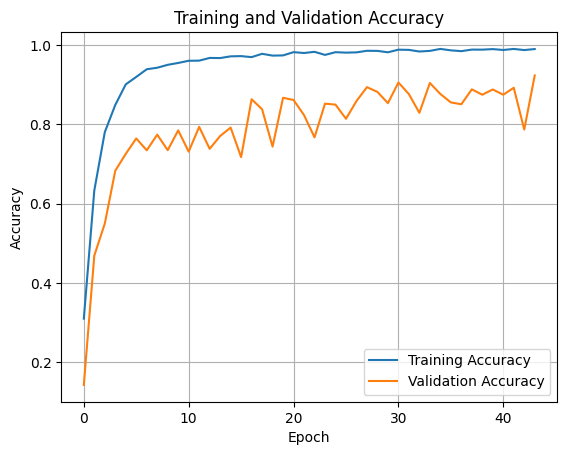

In [35]:
import matplotlib.pyplot as plt

# Extract training and validation accuracy from history
train_acc = history3.history['accuracy']
val_acc = history3.history['val_accuracy']

# Create the plot
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
from keras import backend
from keras import layers
from keras.applications import imagenet_utils
from tensorflow.keras.models import Model
from keras_applications.imagenet_utils import _obtain_input_shape

BASE_WEIGHTS_PATH = (
    "https://storage.googleapis.com/tensorflow/keras-applications/densenet/"
)
DENSENET121_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet121_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET121_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5"
)
DENSENET169_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet169_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET169_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet169_weights_tf_dim_ordering_tf_kernels_notop.h5"
)
DENSENET201_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet201_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET201_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet201_weights_tf_dim_ordering_tf_kernels_notop.h5"
)


def dense_block(x, blocks, name):
    
    for i in range(blocks):
        x = conv_block(x, 32, name=name + "_block" + str(i + 1))
    return x


def transition_block(x, reduction, name):
    
    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1
    x = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_bn"
    )(x)
    x = layers.Activation("relu", name=name + "_relu")(x)
    x = layers.Conv2D(
        int(x.shape[bn_axis] * reduction),
        1,
        use_bias=False,
        name=name + "_conv",
    )(x)
    x = layers.AveragePooling2D(2, strides=2, name=name + "_pool")(x)
    return x


def conv_block(x, growth_rate, name):
    
    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1
    x1 = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_0_bn"
    )(x)
    x1 = layers.Activation("relu", name=name + "_0_relu")(x1)
    x1 = layers.Conv2D(
        4 * growth_rate, 1, use_bias=False, name=name + "_1_conv"
    )(x1)
    x1 = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_1_bn"
    )(x1)
    x1 = layers.Activation("relu", name=name + "_1_relu")(x1)
    x1 = layers.Conv2D(
        growth_rate, 3, padding="same", use_bias=False, name=name + "_2_conv"
    )(x1)
    x = layers.Concatenate(axis=bn_axis, name=name + "_concat")([x, x1])
    return x


def DenseNet(
    blocks,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    
    if backend.image_data_format() == "channels_first":
        raise ValueError(
            "DenseNet does not support the channels_first image data "
            "format. Switch to channels_last by editing your local "
            "config file at ~/.keras/keras.json"
        )
    if not (weights in {"imagenet", None} or file_utils.exists(weights)):
        raise ValueError(
            "The weights argument should be either "
            "None (random initialization), imagenet "
            "(pre-training on ImageNet), "
            "or the path to the weights file to be loaded."
        )

    if weights == "imagenet" and include_top and classes != 1000:
        raise ValueError(
            'If using weights as "imagenet" with include_top'
            " as true, classes should be 1000"
        )

    # Determine proper input shape
    input_shape = _obtain_input_shape(
        input_shape,
        default_size=224,
        min_size=32,
        data_format=backend.image_data_format(),
        require_flatten=include_top,
        weights=weights,
    )

    if input_tensor is None:
        img_input = layers.Input(shape=input_shape)
    else:
        if not backend.is_keras_tensor(input_tensor):
            img_input = layers.Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1

    x = layers.ZeroPadding2D(padding=((3, 3), (3, 3)))(img_input)
    x = layers.Conv2D(64, 7, strides=2, use_bias=False, name="conv1m1")(x)
    x = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name="conv"
    )(x)
    x = layers.Activation("relu", name="conv1_relu")(x)
    x = layers.ZeroPadding2D(padding=((1, 1), (1, 1)))(x)
    x = layers.MaxPooling2D(3, strides=2, name="pool1")(x)

    x = dense_block(x, blocks[0], name="conv2m1")
    x = transition_block(x, 0.5, name="pool2")
    x = dense_block(x, blocks[1], name="conv3m1")
    x = transition_block(x, 0.5, name="pool3")
    x = dense_block(x, blocks[2], name="conv4m1")
    x = transition_block(x, 0.5, name="pool4")
    x = dense_block(x, blocks[3], name="conv5m1")

    x = layers.BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name="bn")(x)
    x = layers.Activation("relu", name="relu")(x)

    if include_top:
        x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
        x = layers.Dense(classes, activation=classifier_activation, name="predictions")(x)
    else:
        if pooling == "avg":
            x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
        elif pooling == "max":
            x = layers.GlobalMaxPooling2D(name="max_pool")(x)

    # Ensure that the model takes into account
    # any potential predecessors of input_tensor.
    if input_tensor is not None:
        inputs = operation_utils.get_source_inputs(input_tensor)
    else:
        inputs = img_input

    # Create model.
    if blocks == [6, 12, 24, 16]:
        model = Model(inputs, x, name="densenet121")
    elif blocks == [6, 12, 32, 32]:
        model = Model(inputs, x, name="densenet169")
    elif blocks == [6, 12, 48, 32]:
        model = Model(inputs, x, name="densenet201")
    else:
        model = Model(inputs, x, name="densenet")

    # Load weights.
    if weights == "imagenet":
        if include_top:
            if blocks == [6, 12, 24, 16]:
                weights_path = file_utils.get_file(
                    "densenet121_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET121_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="9d60b8095a5708f2dcce2bca79d332c7",
                )
            elif blocks == [6, 12, 32, 32]:
                weights_path = file_utils.get_file(
                    "densenet169_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET169_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="d699b8f76981ab1b30698df4c175e90b",
                )
            elif blocks == [6, 12, 48, 32]:
                weights_path = file_utils.get_file(
                    "densenet201_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET201_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="1ceb130c1ea1b78c3bf6114dbdfd8807",
                )
        else:
            if blocks == [6, 12, 24, 16]:
                weights_path = file_utils.get_file(
                    "densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET121_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="30ee3e1110167f948a6b9946edeeb738",
                )
            elif blocks == [6, 12, 32, 32]:
                weights_path = file_utils.get_file(
                    "densenet169_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET169_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="b8c4d4c20dd625c148057b9ff1c1176b",
                )
            elif blocks == [6, 12, 48, 32]:
                weights_path = file_utils.get_file(
                    "densenet201_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET201_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="c13680b51ded0fb44dff2d8f86ac8bb1",
                )
        model.load_weights(weights_path)
    elif weights is not None:
        model.load_weights(weights)

    return model




def DenseNet121(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet121 architecture."""
    return DenseNet(
        [6, 12, 24, 16],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )




def DenseNet169(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet169 architecture."""
    return DenseNet(
        [6, 12, 32, 32],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )




def DenseNet201(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet201 architecture."""
    return DenseNet(
        [6, 12, 48, 32],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )


def preprocess_input(x, data_format=None):
    return imagenet_utils.preprocess_input(
        x, data_format=data_format, mode="torch"
    )


def decode_predictions(preds, top=5):
    return imagenet_utils.decode_predictions(preds, top=top)

In [41]:
model4 = DenseNet121(include_top=True, weights=None, input_tensor=None,input_shape=(64, 64, 3), classes=13)
model4.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [42]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.953:
            self.model.stop_training = True

# Instantiate the custom callback
callback2 = CustomCallback()

In [43]:
history2 = model4.fit(x_train_bls,y_train_one_hot,epochs=80,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks = callback2)

Epoch 1/80
  2/395 ━━━━━━━━━━━━━━━━━━━━ 38s 97ms/step - accuracy: 0.0742 - loss: 3.0802     

W0000 00:00:1715711420.646597     204 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.5438 - loss: 1.4293

W0000 00:00:1715711519.122232     204 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1715711528.853648     204 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


395/395 ━━━━━━━━━━━━━━━━━━━━ 257s 306ms/step - accuracy: 0.5442 - loss: 1.4281 - val_accuracy: 0.1285 - val_loss: 3.9523
Epoch 2/80
  1/395 ━━━━━━━━━━━━━━━━━━━━ 57s 146ms/step - accuracy: 0.8906 - loss: 0.3429

W0000 00:00:1715711541.397418     204 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


395/395 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.8750 - loss: 0.3943 - val_accuracy: 0.4881 - val_loss: 1.9774
Epoch 3/80
395/395 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.9412 - loss: 0.1864 - val_accuracy: 0.6814 - val_loss: 1.1718
Epoch 4/80
395/395 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.9561 - loss: 0.1404 - val_accuracy: 0.6974 - val_loss: 1.1378
Epoch 5/80
395/395 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.9721 - loss: 0.0887 - val_accuracy: 0.8277 - val_loss: 0.5876
Epoch 6/80
395/395 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.9702 - loss: 0.0940 - val_accuracy: 0.7735 - val_loss: 0.9021
Epoch 7/80
395/395 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.9743 - loss: 0.0819 - val_accuracy: 0.7920 - val_loss: 0.7445
Epoch 8/80
395/395 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.9774 - loss: 0.0718 - val_accuracy: 0.8468 - val_loss: 0.5736
Epoch 9/80
395/395 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.9809 - loss: 0.0602 - val_accurac

In [44]:
vit_predictions = model1.predict(x_test)

 25/102 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

W0000 00:00:1715713067.801701     204 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step


W0000 00:00:1715713070.836986     203 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [45]:
OCTpredictions = model2.predict(x_test)

 10/102 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

W0000 00:00:1715713100.993028     202 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 34s 177ms/step


W0000 00:00:1715713118.888910     203 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [46]:
Dense_predictions = model4.predict(x_test)

 12/102 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

W0000 00:00:1715713134.120415     202 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 30s 148ms/step


In [47]:
predictions = model3.predict(x_test)

102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step


In [49]:
combined_predictions1 = np.concatenate((predictions,OCTpredictions,vit_predictions),axis=1)

In [50]:
combined_predictions2 = np.concatenate((Dense_predictions,OCTpredictions,vit_predictions),axis=1)

In [51]:
combined_predictions3 = np.concatenate((predictions,Dense_predictions,OCTpredictions,vit_predictions),axis=1)

# Mobile+Octave+FS

In [52]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
meta_learner = LogisticRegression()


meta_learner.fit(combined_predictions1, y_test)

# Make ensemble predictions
ensemble_predictions1 = meta_learner.predict(combined_predictions1)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions1)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9688751926040061


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Precision: 0.9689768259659073
Recall: 0.9688751926040061
F1-score: 0.9688676499043213
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       140
           1       0.98      0.98      0.98        94
           2       0.97      0.92      0.94        95
           3       0.99      0.99      0.99       107
           4       0.96      0.97      0.96       491
           5       0.97      0.96      0.97       231
           6       0.95      0.94      0.94       171
           7       0.95      0.96      0.95       436
           8       0.98      0.95      0.96       214
           9       0.96      0.97      0.97       463
          10       0.98      0.98      0.98       380
          11       0.99      0.98      0.99       254
          12       0.99      1.00      1.00       169

    accuracy                           0.97      3245
   macro avg       0.97      0.97      0.97      3245
weighted avg       0.97  

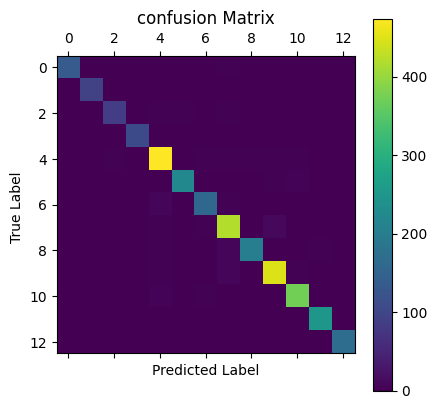

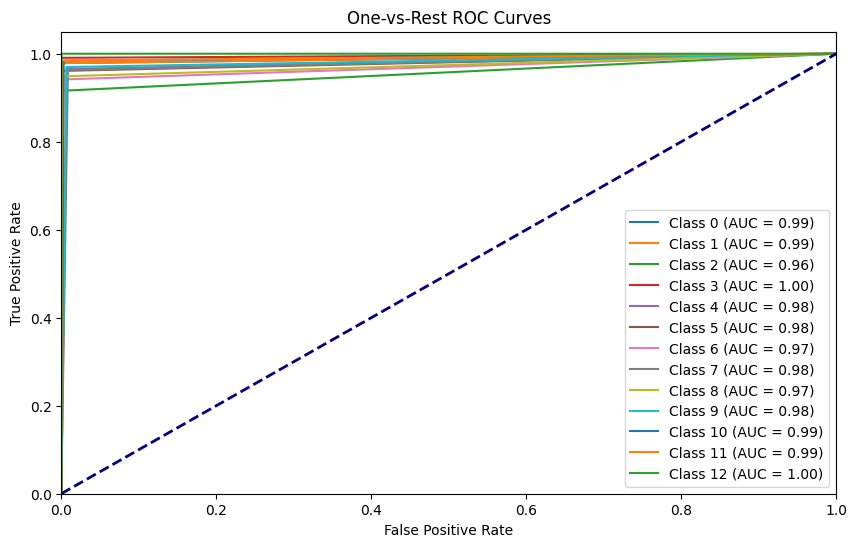

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

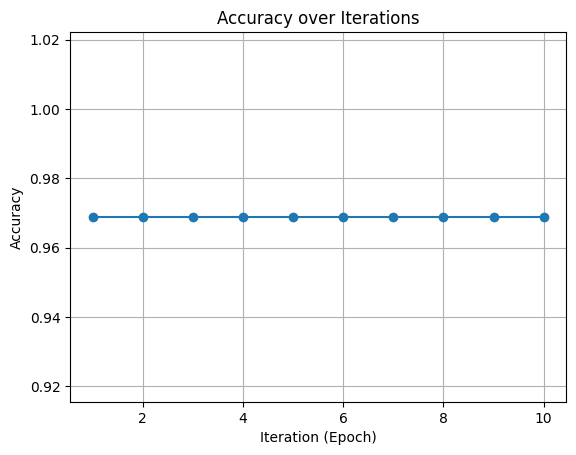

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

precision = precision_score(y_test, ensemble_predictions1, average='weighted')
recall = recall_score(y_test, ensemble_predictions1, average='weighted')
f1 = f1_score(y_test, ensemble_predictions1, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions1)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions1) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions1]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions1)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions1, y_test)
    
    # Make ensemble predictions
    ensemble_predictions1 = meta_learner.predict(combined_predictions1)
    
    # Calculate accuracy
    ensemble_accuracy1 = accuracy_score(y_test, ensemble_predictions1)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy1)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Dense+Octave+FS

In [55]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
meta_learner = LogisticRegression()


meta_learner.fit(combined_predictions2, y_test)

# Make ensemble predictions
ensemble_predictions2 = meta_learner.predict(combined_predictions2)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions2)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9750385208012327


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Precision: 0.9751423463649863
Recall: 0.9750385208012327
F1-score: 0.9750225415929215
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       140
           1       0.99      0.98      0.98        94
           2       1.00      0.94      0.97        95
           3       0.98      1.00      0.99       107
           4       0.97      0.98      0.97       491
           5       0.99      0.97      0.98       231
           6       0.95      0.94      0.94       171
           7       0.97      0.96      0.96       436
           8       0.95      0.97      0.96       214
           9       0.97      0.98      0.97       463
          10       0.98      0.99      0.98       380
          11       0.99      0.98      0.99       254
          12       0.99      1.00      1.00       169

    accuracy                           0.98      3245
   macro avg       0.98      0.97      0.98      3245
weighted avg       0.98  

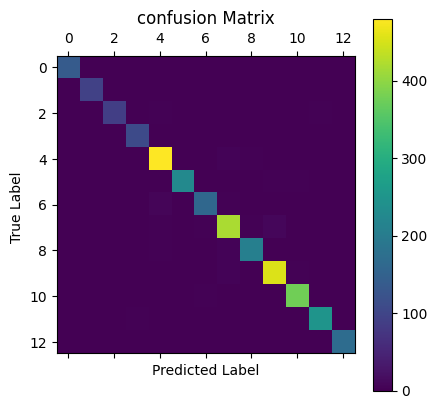

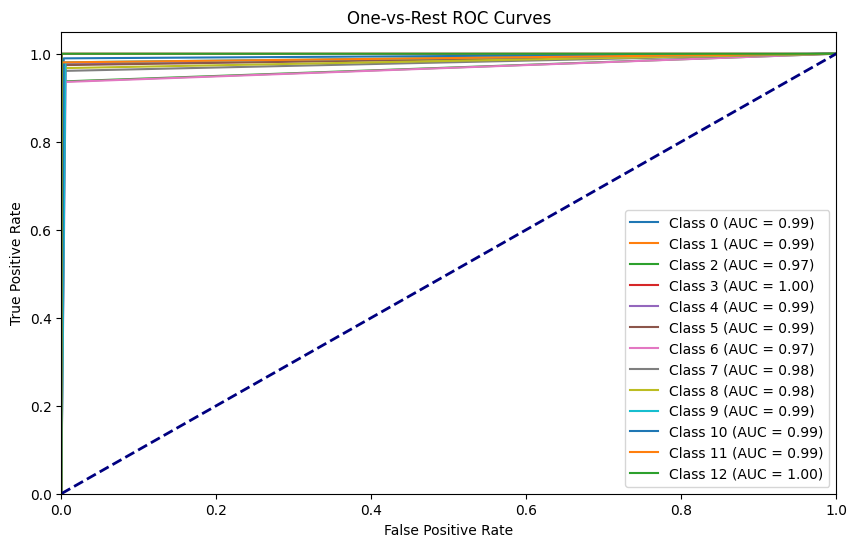

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

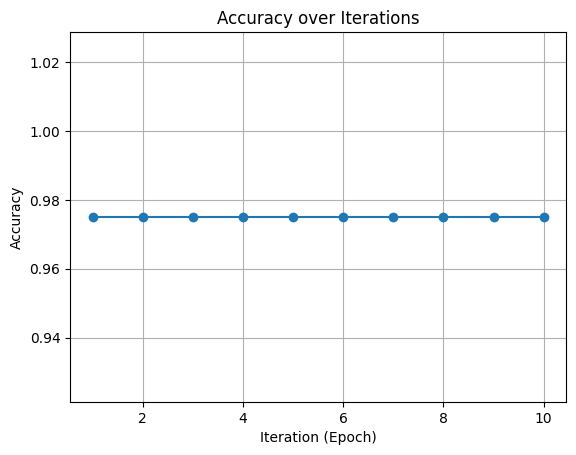

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

precision = precision_score(y_test, ensemble_predictions2, average='weighted')
recall = recall_score(y_test, ensemble_predictions2, average='weighted')
f1 = f1_score(y_test, ensemble_predictions2, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions2)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions2) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions2]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions2)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions2, y_test)
    
    # Make ensemble predictions
    ensemble_predictions2 = meta_learner.predict(combined_predictions2)
    
    # Calculate accuracy
    ensemble_accuracy2 = accuracy_score(y_test, ensemble_predictions2)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy2)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Mobile+Dense+Octave+FS

In [57]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
meta_learner = LogisticRegression()


meta_learner.fit(combined_predictions3, y_test)

# Make ensemble predictions
ensemble_predictions3 = meta_learner.predict(combined_predictions3)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions3)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9784283513097073


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Precision: 0.9784946040897385
Recall: 0.9784283513097073
F1-score: 0.9784196316898294
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       140
           1       1.00      0.99      0.99        94
           2       0.99      0.96      0.97        95
           3       0.99      1.00      1.00       107
           4       0.97      0.98      0.97       491
           5       0.99      0.98      0.99       231
           6       0.96      0.94      0.95       171
           7       0.97      0.97      0.97       436
           8       0.97      0.97      0.97       214
           9       0.97      0.98      0.98       463
          10       0.98      0.99      0.99       380
          11       1.00      0.98      0.99       254
          12       0.99      1.00      1.00       169

    accuracy                           0.98      3245
   macro avg       0.98      0.98      0.98      3245
weighted avg       0.98  

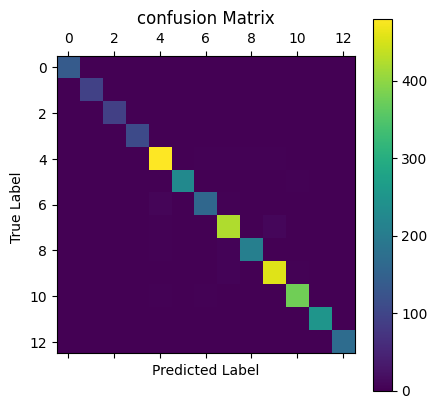

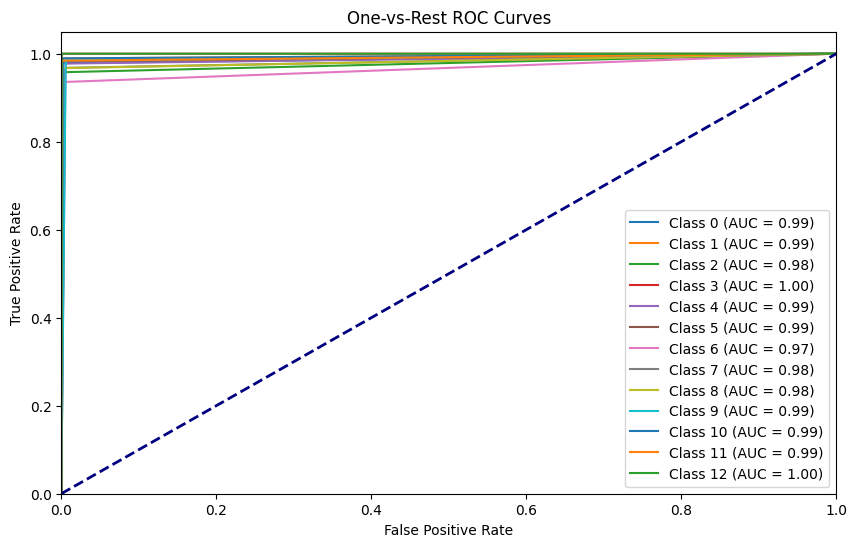

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

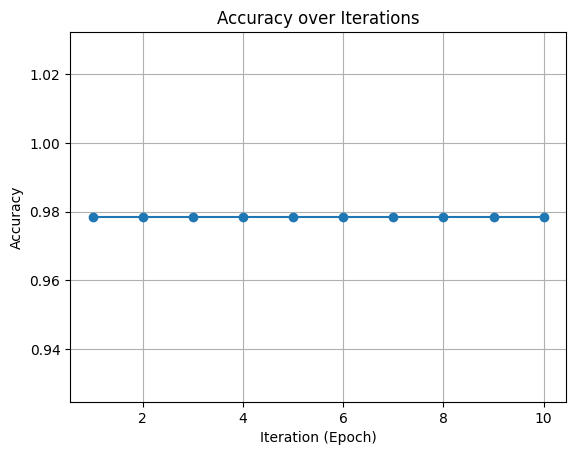

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

precision = precision_score(y_test, ensemble_predictions3, average='weighted')
recall = recall_score(y_test, ensemble_predictions3, average='weighted')
f1 = f1_score(y_test, ensemble_predictions3, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions3)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions3) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions3]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions3)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions3, y_test)
    
    # Make ensemble predictions
    ensemble_predictions3 = meta_learner.predict(combined_predictions3)
    
    # Calculate accuracy
    ensemble_accuracy3 = accuracy_score(y_test, ensemble_predictions3)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy3)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Mobile+FS

In [59]:
combined_predictions4 = np.concatenate((predictions,vit_predictions),axis=1)

In [60]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
meta_learner = LogisticRegression()


meta_learner.fit(combined_predictions4, y_test)

# Make ensemble predictions
ensemble_predictions4 = meta_learner.predict(combined_predictions4)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions4)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9546995377503852


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Precision: 0.9549467333066692
Recall: 0.9546995377503852
F1-score: 0.954656616976458
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97       140
           1       0.97      0.98      0.97        94
           2       0.97      0.91      0.93        95
           3       0.98      0.98      0.98       107
           4       0.94      0.95      0.95       491
           5       0.96      0.93      0.94       231
           6       0.95      0.94      0.94       171
           7       0.91      0.94      0.93       436
           8       0.95      0.90      0.92       214
           9       0.96      0.97      0.96       463
          10       0.97      0.98      0.97       380
          11       0.97      0.98      0.98       254
          12       0.99      0.99      0.99       169

    accuracy                           0.95      3245
   macro avg       0.96      0.95      0.96      3245
weighted avg       0.95   

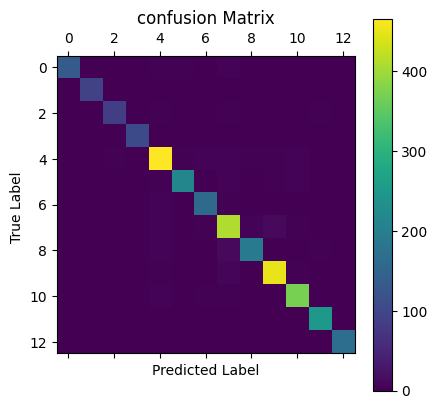

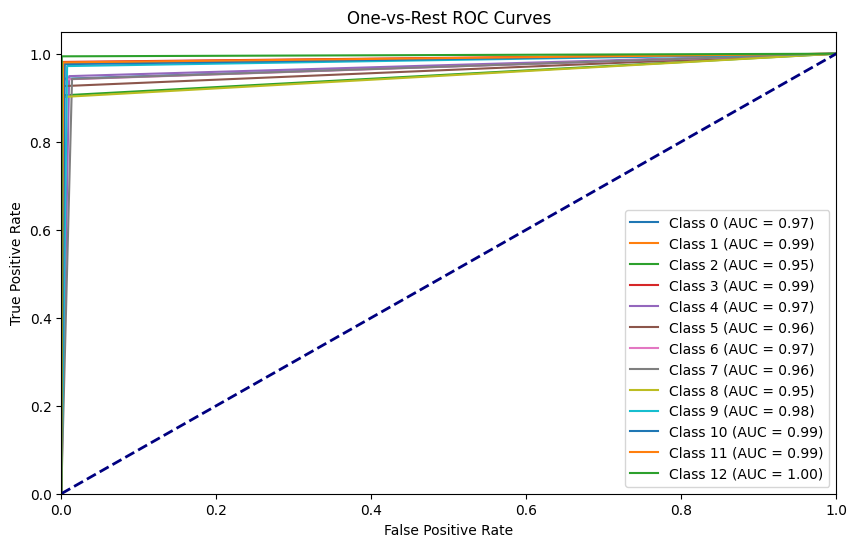

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

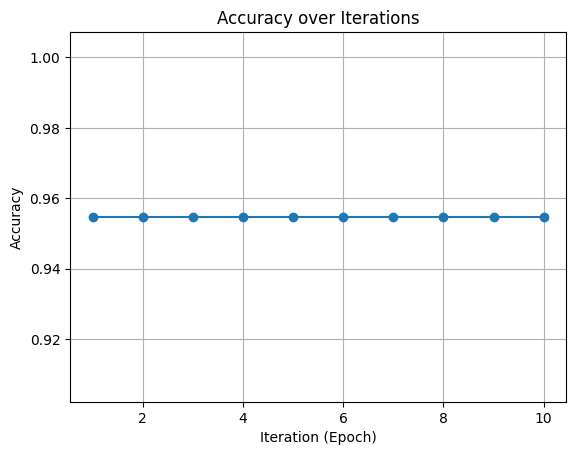

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

precision = precision_score(y_test, ensemble_predictions4, average='weighted')
recall = recall_score(y_test, ensemble_predictions4, average='weighted')
f1 = f1_score(y_test, ensemble_predictions4, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions4)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions4) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions4]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions4)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions4, y_test)
    
    # Make ensemble predictions
    ensemble_predictions4 = meta_learner.predict(combined_predictions4)
    
    # Calculate accuracy
    ensemble_accuracy4 = accuracy_score(y_test, ensemble_predictions4)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy4)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Dense+FS

In [62]:
combined_predictions5 = np.concatenate((Dense_predictions,vit_predictions),axis=1)

In [63]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
meta_learner = LogisticRegression()


meta_learner.fit(combined_predictions5, y_test)

# Make ensemble predictions
ensemble_predictions5 = meta_learner.predict(combined_predictions5)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions5)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9691833590138675


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Precision: 0.9692578338959836
Recall: 0.9691833590138675
F1-score: 0.9691785025679472
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       140
           1       1.00      0.98      0.99        94
           2       0.98      0.96      0.97        95
           3       0.98      0.99      0.99       107
           4       0.96      0.96      0.96       491
           5       0.97      0.97      0.97       231
           6       0.95      0.94      0.94       171
           7       0.96      0.96      0.96       436
           8       0.95      0.94      0.95       214
           9       0.97      0.98      0.97       463
          10       0.98      0.99      0.98       380
          11       0.99      0.97      0.98       254
          12       0.99      1.00      1.00       169

    accuracy                           0.97      3245
   macro avg       0.97      0.97      0.97      3245
weighted avg       0.97  

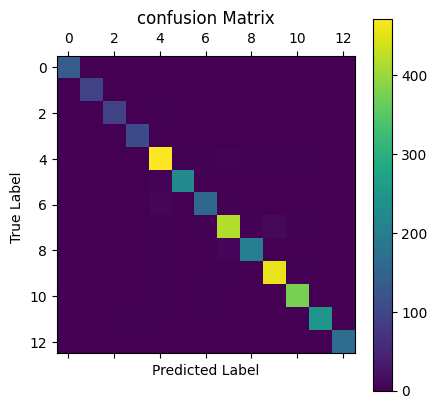

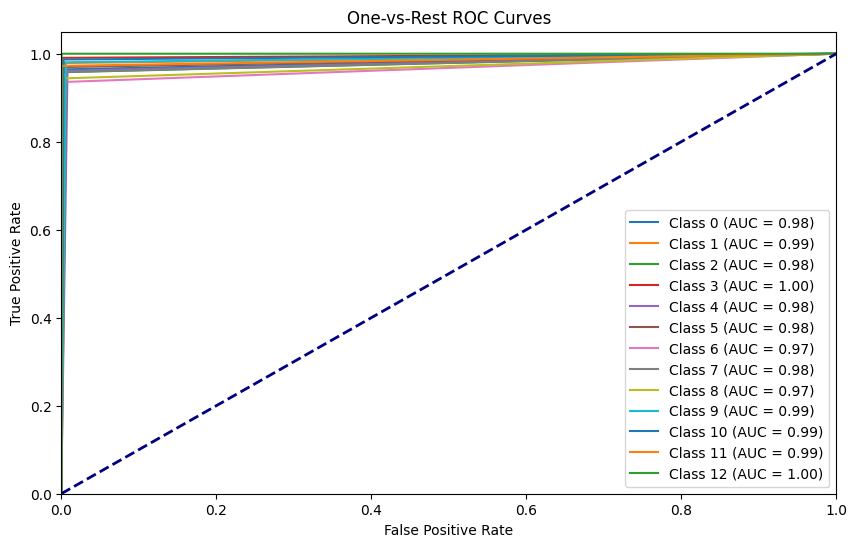

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

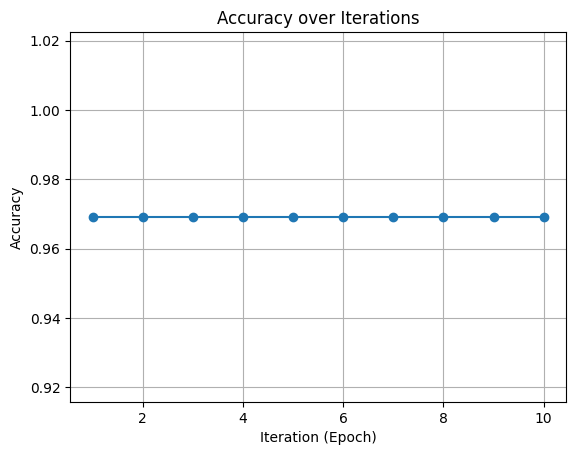

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

precision = precision_score(y_test, ensemble_predictions5, average='weighted')
recall = recall_score(y_test, ensemble_predictions5, average='weighted')
f1 = f1_score(y_test, ensemble_predictions5, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions5)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions4) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions5]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions5)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions5, y_test)
    
    # Make ensemble predictions
    ensemble_predictions5 = meta_learner.predict(combined_predictions5)
    
    # Calculate accuracy
    ensemble_accuracy5 = accuracy_score(y_test, ensemble_predictions5)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy5)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Mobile+Dense+FS

In [65]:
combined_predictions6 = np.concatenate((predictions,Dense_predictions,vit_predictions),axis=1)

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ensemble Accuracy: 0.9731895223420647
Precision: 0.9732799567916769
Recall: 0.9731895223420647
F1-score: 0.9731798484162976
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       140
           1       1.00      0.98      0.99        94
           2       0.98      0.95      0.96        95
           3       0.99      1.00      1.00       107
           4       0.96      0.96      0.96       491
           5       0.98      0.97      0.98       231
           6       0.95      0.94      0.95       171
           7       0.95      0.97      0.96       436
           8       0.97      0.95      0.96       214
           9       0.97      0.99      0.98       463
          10       0.98      0.98      0.98       380
          11       0.99      0.98      0.99       254
          12       0.99      1.00      1.00       169

    accuracy                           0.97      3245
   macro avg       0.98      0.97      0.

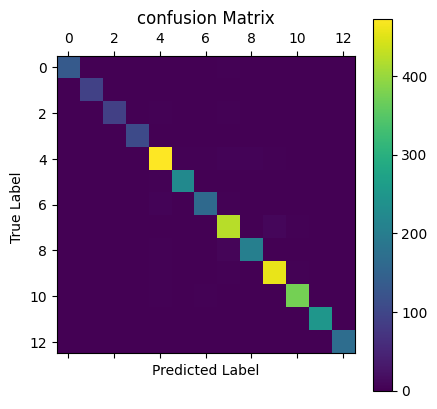

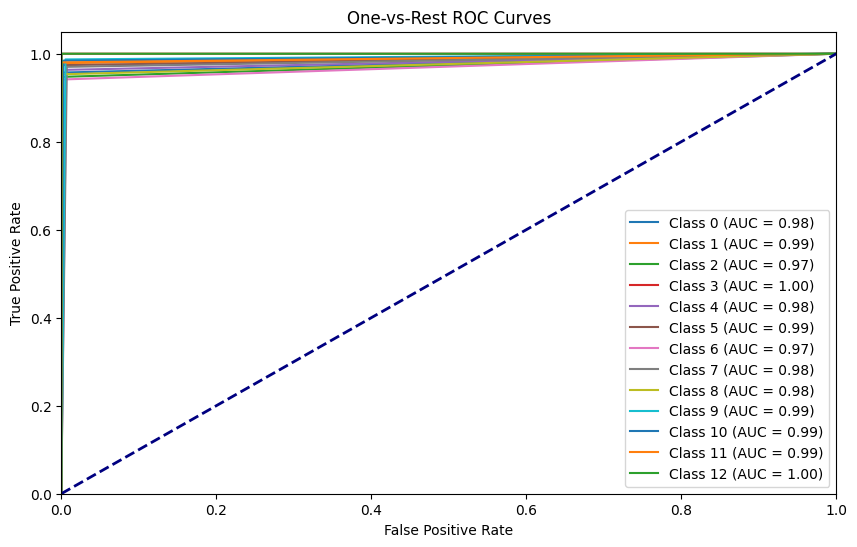

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

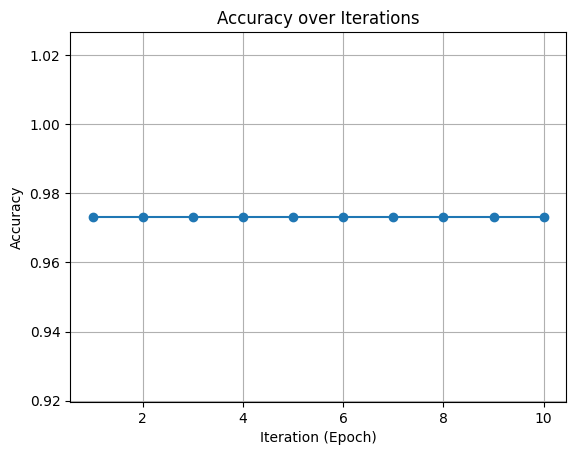

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

meta_learner.fit(combined_predictions6, y_test)

# Make ensemble predictions
ensemble_predictions6 = meta_learner.predict(combined_predictions6)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions6)
print(f'Ensemble Accuracy: {ensemble_accuracy}')


precision = precision_score(y_test, ensemble_predictions6, average='weighted')
recall = recall_score(y_test, ensemble_predictions6, average='weighted')
f1 = f1_score(y_test, ensemble_predictions6, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions6)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions6) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions6]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions6)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions6, y_test)
    
    # Make ensemble predictions
    ensemble_predictions6 = meta_learner.predict(combined_predictions6)
    
    # Calculate accuracy
    ensemble_accuracy6 = accuracy_score(y_test, ensemble_predictions6)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy6)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Dense+Octave+FS

In [67]:
combined_predictions7 = np.concatenate((Dense_predictions,OCTpredictions,vit_predictions),axis=1)

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ensemble Accuracy: 0.9750385208012327
Precision: 0.9751423463649863
Recall: 0.9750385208012327
F1-score: 0.9750225415929215
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       140
           1       0.99      0.98      0.98        94
           2       1.00      0.94      0.97        95
           3       0.98      1.00      0.99       107
           4       0.97      0.98      0.97       491
           5       0.99      0.97      0.98       231
           6       0.95      0.94      0.94       171
           7       0.97      0.96      0.96       436
           8       0.95      0.97      0.96       214
           9       0.97      0.98      0.97       463
          10       0.98      0.99      0.98       380
          11       0.99      0.98      0.99       254
          12       0.99      1.00      1.00       169

    accuracy                           0.98      3245
   macro avg       0.98      0.97      0.

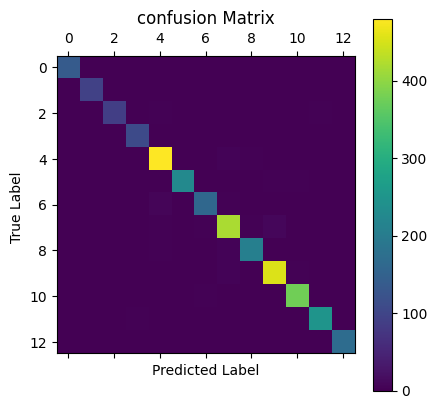

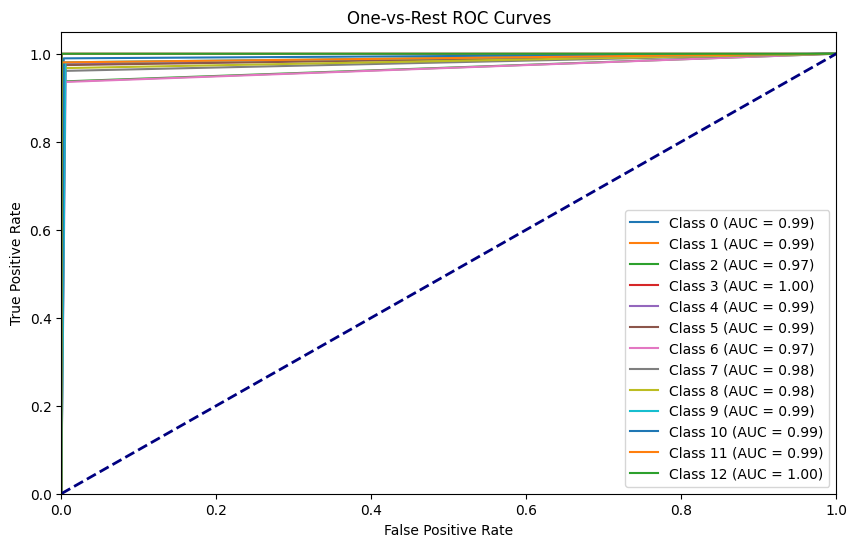

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

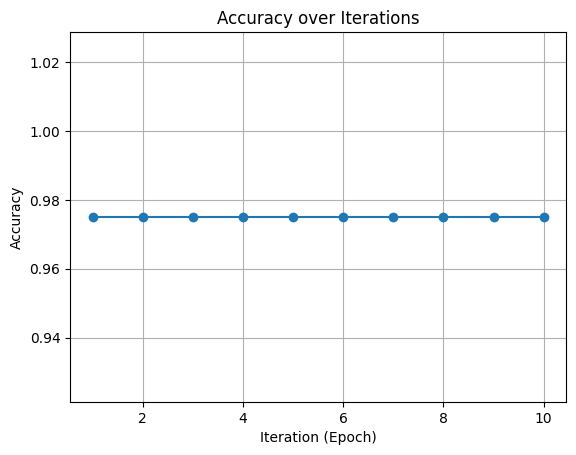

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

meta_learner.fit(combined_predictions7, y_test)

# Make ensemble predictions
ensemble_predictions7 = meta_learner.predict(combined_predictions7)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions7)
print(f'Ensemble Accuracy: {ensemble_accuracy}')


precision = precision_score(y_test, ensemble_predictions7, average='weighted')
recall = recall_score(y_test, ensemble_predictions7, average='weighted')
f1 = f1_score(y_test, ensemble_predictions7, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions7)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions7) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions7]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions7)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions7, y_test)
    
    # Make ensemble predictions
    ensemble_predictions7 = meta_learner.predict(combined_predictions7)
    
    # Calculate accuracy
    ensemble_accuracy7 = accuracy_score(y_test, ensemble_predictions7)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy7)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

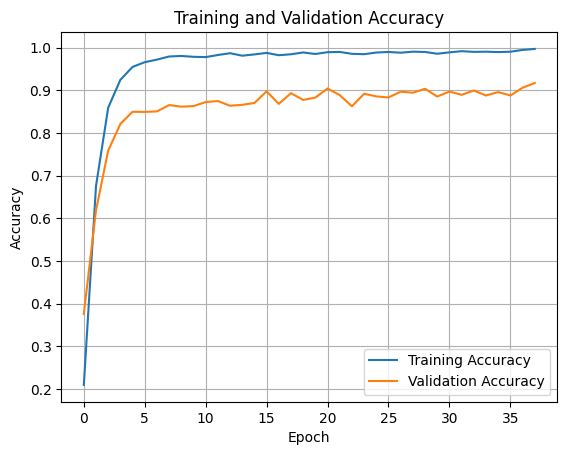

In [72]:
import matplotlib.pyplot as plt

# Extract training and validation accuracy from history
train_acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

# Create the plot
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

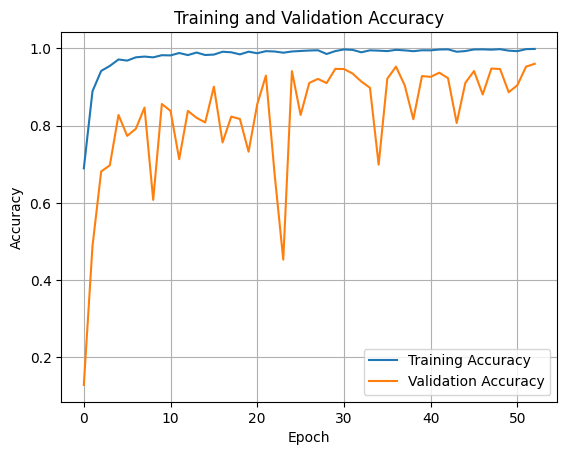

In [73]:
import matplotlib.pyplot as plt

# Extract training and validation accuracy from history
train_acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']

# Create the plot
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

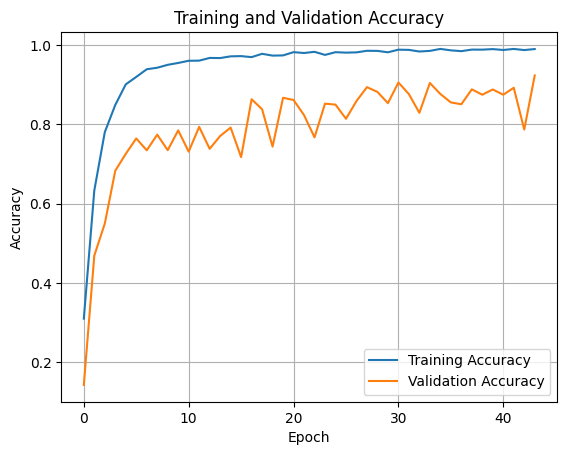

In [74]:
import matplotlib.pyplot as plt

# Extract training and validation accuracy from history
train_acc = history3.history['accuracy']
val_acc = history3.history['val_accuracy']

# Create the plot
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [75]:
loss,accuracy = model4.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)

  9/102 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9703 - loss: 0.2044

W0000 00:00:1715715003.584475     204 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.9651 - loss: 0.2177
testing accuracy: 0.9602465033531189


In [76]:
loss,accuracy = model4.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)


loss = history1.history['loss'][-1]

print("Final Loss:", loss)


y_pred2 = model4.predict(x_test)

import numpy as np

# Assuming y_pred is continuous probabilities
threshold = 0.5  # Set your desired threshold here
y_pred_binary2 = np.where(y_pred2 >= threshold, 1, 0)

# Now y_pred_binary contains binary predictions based on the threshold


precision = precision_score(y_test_one_hot, y_pred_binary2,average='micro')
print("Precision:", precision)

recall = recall_score(y_test_one_hot, y_pred_binary2,average='micro')
print("Recall:", recall)

f1 = f1_score(y_test_one_hot, y_pred_binary2,average='micro')
print("F1 Score:", f1)

auc_roc = roc_auc_score(y_test_one_hot, y_pred_binary2,average='micro')
print("AUC-ROC Score:", auc_roc)


class_report = classification_report(y_test_one_hot, y_pred_binary2)
print("Classification Report:")
print(class_report)

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9651 - loss: 0.2177
testing accuracy: 0.9602465033531189
Final Loss: 0.010446708649396896
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Precision: 0.9643742255266419
Recall: 0.9593220338983051
F1 Score: 0.9618414954426077
AUC-ROC Score: 0.9781843862352336
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       140
           1       0.96      0.97      0.96        94
           2       0.99      0.95      0.97        95
           3       0.96      1.00      0.98       107
           4       0.96      0.95      0.95       491
           5       0.94      0.97      0.95       231
           6       0.97      0.93      0.95       171
           7       0.95      0.95      0.95       436
           8       0.97      0.93      0.95       214
           9       0.96      0.97      0.96       463
          10       0.97      0.97      0.97       380
          11       0

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [77]:
combined_predictions10 = np.concatenate((predictions,Dense_predictions,OCTpredictions),axis=1)

Ensemble Accuracy: 0.9707241910631741
Precision: 0.9708444699684661
Recall: 0.9707241910631741
F1-score: 0.9707134079500533
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       140
           1       0.99      0.98      0.98        94
           2       0.99      0.95      0.97        95
           3       0.97      0.99      0.98       107
           4       0.96      0.97      0.97       491
           5       0.98      0.97      0.97       231
           6       0.97      0.93      0.95       171
           7       0.96      0.97      0.96       436
           8       0.96      0.95      0.96       214
           9       0.96      0.98      0.97       463
          10       0.98      0.98      0.98       380
          11       0.99      0.98      0.98       254
          12       0.99      1.00      1.00       169

    accuracy                           0.97      3245
   macro avg       0.98      0.97      0.

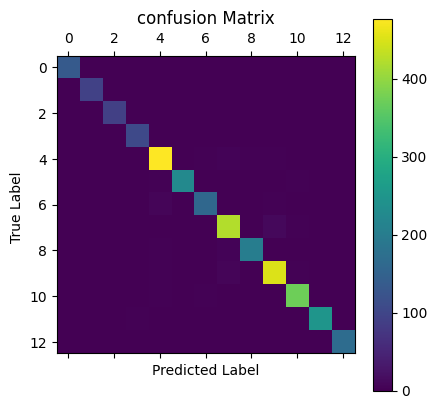

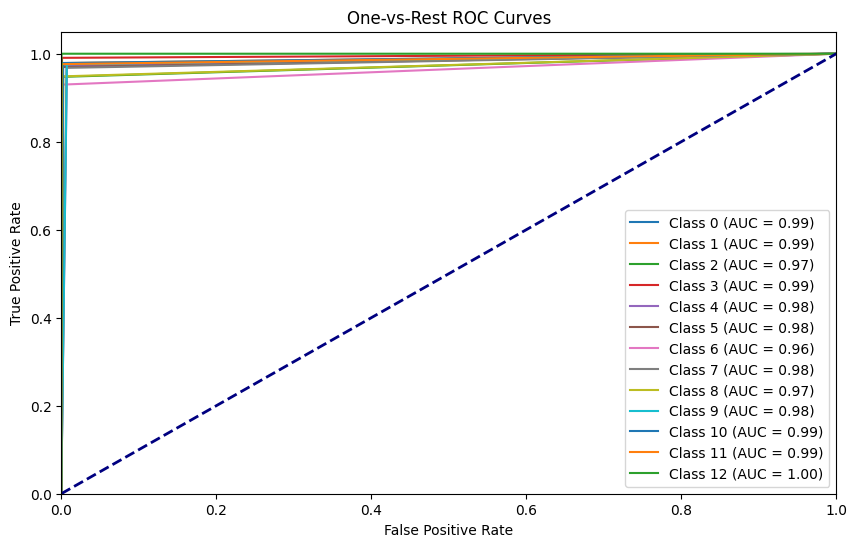

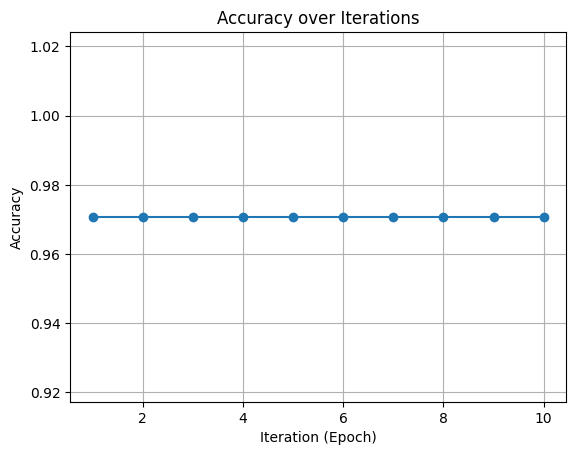

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

meta_learner.fit(combined_predictions10, y_test)

# Make ensemble predictions
ensemble_predictions10 = meta_learner.predict(combined_predictions10)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions10)
print(f'Ensemble Accuracy: {ensemble_accuracy}')


precision = precision_score(y_test, ensemble_predictions10, average='weighted')
recall = recall_score(y_test, ensemble_predictions10, average='weighted')
f1 = f1_score(y_test, ensemble_predictions10, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions10)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions10) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions10]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions10)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions10, y_test)
    
    # Make ensemble predictions
    ensemble_predictions10 = meta_learner.predict(combined_predictions10)
    
    # Calculate accuracy
    ensemble_accuracy10 = accuracy_score(y_test, ensemble_predictions10)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy10)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

In [79]:
combined_predictions9 = np.concatenate((predictions,Dense_predictions),axis=1)

Ensemble Accuracy: 0.964869029275809
Precision: 0.9649964808326921
Recall: 0.964869029275809
F1-score: 0.9648342403230445
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       140
           1       0.97      0.97      0.97        94
           2       0.99      0.94      0.96        95
           3       0.95      0.98      0.97       107
           4       0.96      0.96      0.96       491
           5       0.95      0.97      0.96       231
           6       0.97      0.93      0.95       171
           7       0.95      0.96      0.95       436
           8       0.97      0.94      0.95       214
           9       0.96      0.98      0.97       463
          10       0.97      0.97      0.97       380
          11       0.99      0.97      0.98       254
          12       0.99      1.00      1.00       169

    accuracy                           0.96      3245
   macro avg       0.97      0.96      0.97

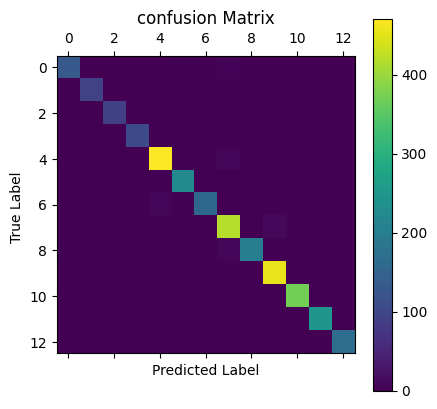

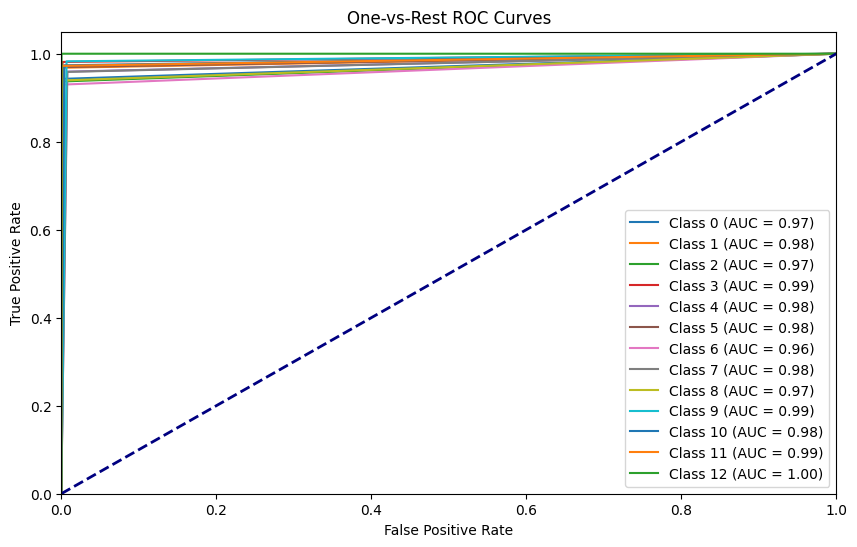

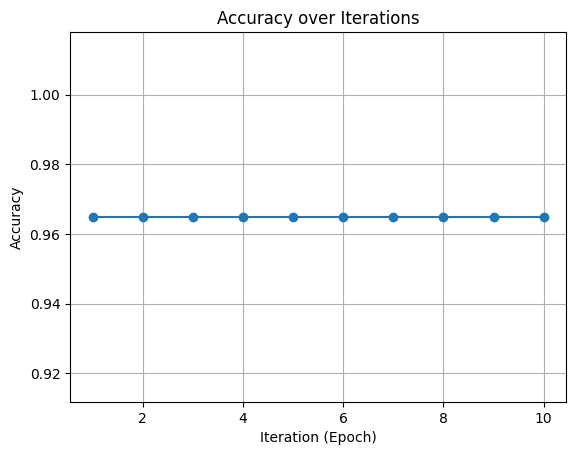

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

meta_learner.fit(combined_predictions9, y_test)

# Make ensemble predictions
ensemble_predictions9 = meta_learner.predict(combined_predictions9)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions9)
print(f'Ensemble Accuracy: {ensemble_accuracy}')


precision = precision_score(y_test, ensemble_predictions9, average='weighted')
recall = recall_score(y_test, ensemble_predictions9, average='weighted')
f1 = f1_score(y_test, ensemble_predictions9, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions9)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions9) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions9]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions9)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions9, y_test)
    
    # Make ensemble predictions
    ensemble_predictions9 = meta_learner.predict(combined_predictions9)
    
    # Calculate accuracy
    ensemble_accuracy9 = accuracy_score(y_test, ensemble_predictions9)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy9)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

In [82]:
combined_predictions8 = np.concatenate((Dense_predictions,OCTpredictions),axis=1)

Ensemble Accuracy: 0.9701078582434515
Precision: 0.9702098882616648
Recall: 0.9701078582434515
F1-score: 0.9700739114143628
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       140
           1       0.98      0.98      0.98        94
           2       0.99      0.94      0.96        95
           3       0.97      0.99      0.98       107
           4       0.96      0.97      0.97       491
           5       0.97      0.97      0.97       231
           6       0.97      0.92      0.95       171
           7       0.96      0.97      0.96       436
           8       0.96      0.95      0.95       214
           9       0.96      0.98      0.97       463
          10       0.98      0.98      0.98       380
          11       0.98      0.97      0.98       254
          12       0.99      1.00      0.99       169

    accuracy                           0.97      3245
   macro avg       0.97      0.97      0.

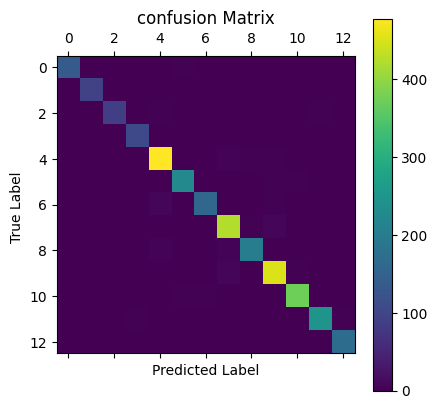

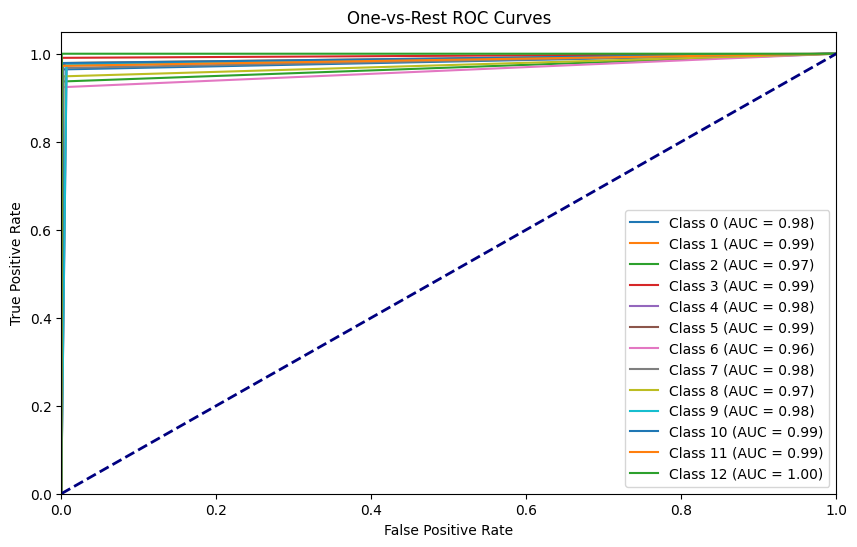

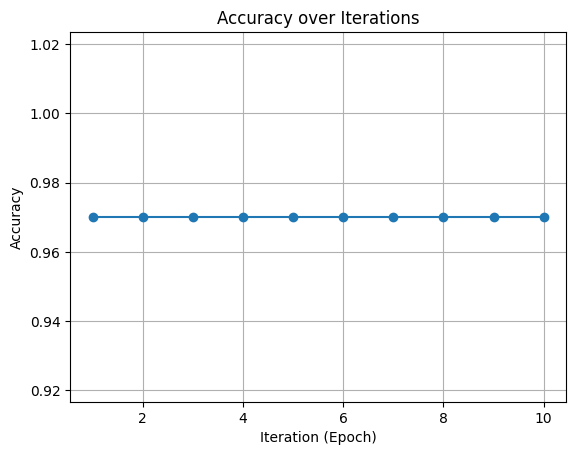

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

meta_learner.fit(combined_predictions8, y_test)

# Make ensemble predictions
ensemble_predictions8 = meta_learner.predict(combined_predictions8)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions8)
print(f'Ensemble Accuracy: {ensemble_accuracy}')


precision = precision_score(y_test, ensemble_predictions8, average='weighted')
recall = recall_score(y_test, ensemble_predictions8, average='weighted')
f1 = f1_score(y_test, ensemble_predictions8, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions8)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions8) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions8]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions8)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions8, y_test)
    
    # Make ensemble predictions
    ensemble_predictions8 = meta_learner.predict(combined_predictions8)
    
    # Calculate accuracy
    ensemble_accuracy8 = accuracy_score(y_test, ensemble_predictions8)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy8)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

In [84]:
combined_predictions11 = np.concatenate((predictions,OCTpredictions),axis=1)

Ensemble Accuracy: 0.9608628659476117
Precision: 0.9612236775418962
Recall: 0.9608628659476117
F1-score: 0.9608077062429394
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       140
           1       0.99      0.98      0.98        94
           2       0.99      0.88      0.93        95
           3       0.95      0.98      0.97       107
           4       0.94      0.97      0.96       491
           5       0.97      0.94      0.95       231
           6       0.96      0.93      0.94       171
           7       0.94      0.96      0.95       436
           8       0.97      0.94      0.96       214
           9       0.96      0.96      0.96       463
          10       0.97      0.98      0.97       380
          11       0.96      0.98      0.97       254
          12       0.99      1.00      0.99       169

    accuracy                           0.96      3245
   macro avg       0.97      0.96      0.

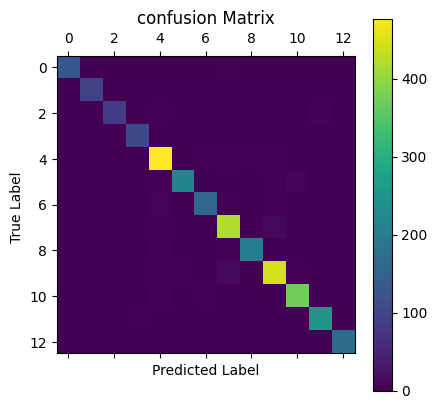

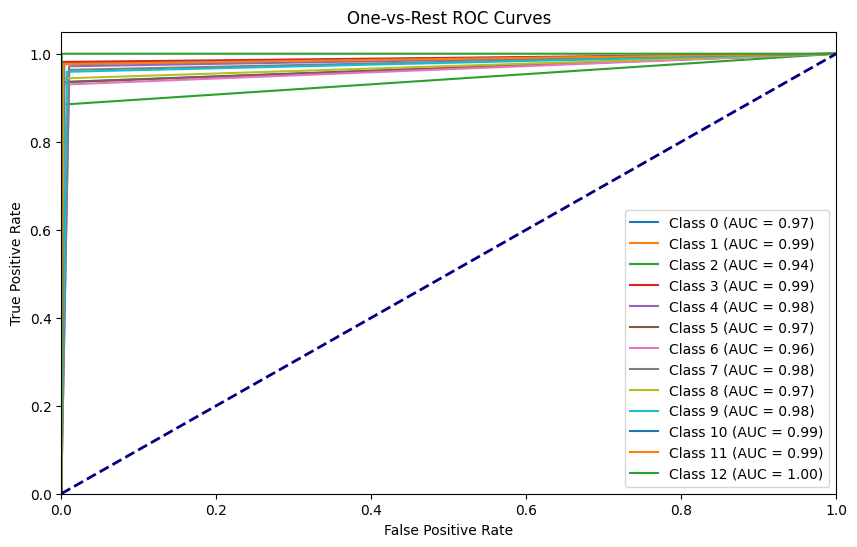

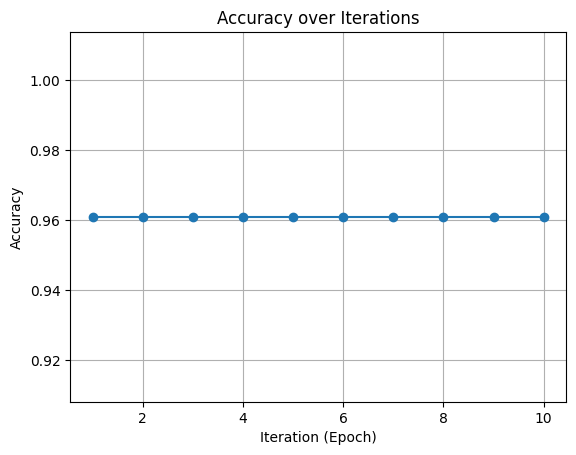

In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

meta_learner.fit(combined_predictions11, y_test)

# Make ensemble predictions
ensemble_predictions11 = meta_learner.predict(combined_predictions11)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions11)
print(f'Ensemble Accuracy: {ensemble_accuracy}')


precision = precision_score(y_test, ensemble_predictions11, average='weighted')
recall = recall_score(y_test, ensemble_predictions11, average='weighted')
f1 = f1_score(y_test, ensemble_predictions11, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions11)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions11) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions11]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions11)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions11, y_test)
    
    # Make ensemble predictions
    ensemble_predictions11 = meta_learner.predict(combined_predictions11)
    
    # Calculate accuracy
    ensemble_accuracy11 = accuracy_score(y_test, ensemble_predictions11)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy11)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()